###### DSM500 - MSc Thesis: Investigating the Performance and Reliability of Deep-Learning Flood Segmentation Under Varying Flood Extent Using Sentinel-1 SAR Imagery
###### 10 August 2026
###### Archie Hulse
###### Student Number: 250410903
##### Notebook 5: 
#                                               05 - <u>Statistical Analysis<u/>
--------------------------------

#### <u>Contents:</u>
###### *(Hyperlinks to sections of this report)*

#### [Go to Section 1](#1) - Imports and Paths

[1.1](#1.1) Notebook Introduction

[1.2](#1.2) Imports & paths

[1.3](#1.3) Load Data

[1.4](#1.4) Build Model Master Results Tables

[1.5](#1.5) Combined Model Training Plot

#### [Go to Section 2](#2) - NaN Audit & Handelling

[2.1](#2.1) NaN Audit & Justification

#### [Go to Section 3](#3) - Descriptive Analyses

[3.1](#3.1) flood extent Descriptive statistics

[3.2](#3.2) Flood Extent vs Segmentation Performance Analysis

[3.3](#3.3) Regression diagnostics

[3.4](#3.4) Sensitivity Analysis

#### [Go to Section 4](#4) - Secondary Validation — Bolivia Holdout

[4.1](#4.1) Bolivia Data Preparation

[4.2](#4.2) Bolivia Holdout Analyses

#### [Go to Section 5](#5) - Qualitative Error Analysis

[5.1](#5.1) Scene-level comparison table

[5.2](#5.2) Flood-extent categories

[5.3](#5.3) Flood Scene Selection

-----------------------
###### 1
## Section 1: Imports & Paths
###### 1.1
### Notebook Introduction:
This notebook analyses the outputs generated by the U-Net and SegFormer-B0 experiments conducted in the previous notebook '04_Model_Training'. It combines the per-scene model performance results with the JRC-adjusted flood-extent measure and performs the statistical and visual analyses required to investigate the relationship between flood extent and segmentation performance.

The principal analysis focuses on the 89 unseen test scenes, while the 15 Bolivia scenes are treated separately as a secondary unseen-event assessment. The analysis includes descriptive statistics, scatterplots, Pearson correlation, simple linear regression and LOWESS visualisation, followed by qualitative examination of representative segmentation results.

-----------------------
###### 1.2
### Section 1.2 - Imports & Paths

In [1]:
# Imports and project paths:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def find_project_root():
    """
    Find the project root directory by locating the first
    parent directory containing both Data and Results.
    """

    current = Path.cwd().resolve()

    for directory in [current] + list(current.parents):
        if (directory / "Data").exists() and (directory / "Results").exists():
            return directory

    raise FileNotFoundError(
        "Could not locate the project root.")


PROJECT_DIR = find_project_root()
RESULTS_DIR = PROJECT_DIR / "results_new"
RESULTS_TABLE_DIR = RESULTS_DIR / "tables"
MODEL_DIR = RESULTS_DIR / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_TABLE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Results directory:", RESULTS_DIR)
print("Results tables:", RESULTS_TABLE_DIR)
print("Model directory:", MODEL_DIR)

Project directory: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project
Results directory: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new
Results tables: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables
Model directory: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/models


-------------------
###### 1.3
### Section 1.3 - Load Data

In [2]:
# Load model evaluation results:

UNET_TEST_FILE = (RESULTS_TABLE_DIR / "unet_test_results.csv")
UNET_BOLIVIA_FILE = (RESULTS_TABLE_DIR / "unet_bolivia_results.csv")

SEGFORMER_TEST_FILE = (RESULTS_TABLE_DIR / "segformer_test_results.csv")
SEGFORMER_BOLIVIA_FILE = (RESULTS_TABLE_DIR / "segformer_bolivia_results.csv")

unet_test = pd.read_csv(UNET_TEST_FILE)
unet_bolivia = pd.read_csv(UNET_BOLIVIA_FILE)

segformer_test = pd.read_csv(SEGFORMER_TEST_FILE)
segformer_bolivia = pd.read_csv(SEGFORMER_BOLIVIA_FILE)

print("U-Net test:", unet_test.shape)
print("U-Net Bolivia:", unet_bolivia.shape)
print("SegFormer test:", segformer_test.shape)
print("SegFormer Bolivia:", segformer_bolivia.shape)

U-Net test: (87, 17)
U-Net Bolivia: (14, 17)
SegFormer test: (87, 17)
SegFormer Bolivia: (14, 17)


In [3]:
# Evaluation-set identifiers:

unet_test = unet_test.copy()
unet_bolivia = unet_bolivia.copy()

segformer_test = segformer_test.copy()
segformer_bolivia = segformer_bolivia.copy()

unet_test["evaluation_set"] = "principal_test"
unet_bolivia["evaluation_set"] = "bolivia_holdout"

segformer_test["evaluation_set"] = "principal_test"
segformer_bolivia["evaluation_set"] = "bolivia_holdout"

print(unet_test["evaluation_set"].value_counts())
print(unet_bolivia["evaluation_set"].value_counts())

evaluation_set
principal_test    87
Name: count, dtype: int64
evaluation_set
bolivia_holdout    14
Name: count, dtype: int64


-----------------
###### 1.4
### Section 1.4 - Master Modelling Results Tables

In [4]:
# Master model-results table:

master_results = pd.concat(
    [
        unet_test,
        unet_bolivia,
        segformer_test,
        segformer_bolivia
    ],
    ignore_index=True)

print("Master results shape:")
print(master_results.shape)
display(master_results.head())

Master results shape:
(202, 18)


,scene_id,flood_event,model,flood_extent,original_water_extent,valid_pixels,water_pixels,permanent_water_pixels,event_water_pixels,TP,FP,TN,FN,IoU,F1,Precision,Recall,evaluation_set
0,Ghana_313799,Ghana,U-Net,6.108466,6.108466,244464,14933,0,14933,279,3,229528,14654,0.018680,0.036674,0.989362,0.018683,principal_test
1,Ghana_1078550,Ghana,U-Net,0.536728,0.536728,262144,1407,0,1407,59,15,260722,1348,0.041491,0.079676,0.797297,0.041933,principal_test
2,Ghana_97059,Ghana,U-Net,0.000000,0.000000,27394,0,0,0,0,322,27072,0,0.000000,0.000000,0.000000,NaN,principal_test
3,Ghana_359826,Ghana,U-Net,1.333618,1.333618,262144,3496,0,3496,1516,325,258323,1980,0.396755,0.568109,0.823466,0.433638,principal_test
4,Ghana_319168,Ghana,U-Net,23.027665,23.027665,171624,39521,0,39521,12851,721,131382,26670,0.319343,0.484094,0.946876,0.325169,principal_test


In [5]:
# Organising master results columns:

preferred_columns = [
    "scene_id",
    "flood_event",
    "model",
    "evaluation_set",

    "flood_extent",
    "original_water_extent",

    "valid_pixels",
    "water_pixels",
    "permanent_water_pixels",
    "event_water_pixels",

    "TP",
    "FP",
    "TN",
    "FN",

    "IoU",
    "F1",
    "Precision",
    "Recall"
]

master_results = master_results[
    [
        column
        for column in preferred_columns
        if column in master_results.columns
    ]
]

display(master_results.head())

,scene_id,flood_event,model,evaluation_set,flood_extent,original_water_extent,valid_pixels,water_pixels,permanent_water_pixels,event_water_pixels,TP,FP,TN,FN,IoU,F1,Precision,Recall
0,Ghana_313799,Ghana,U-Net,principal_test,6.108466,6.108466,244464,14933,0,14933,279,3,229528,14654,0.018680,0.036674,0.989362,0.018683
1,Ghana_1078550,Ghana,U-Net,principal_test,0.536728,0.536728,262144,1407,0,1407,59,15,260722,1348,0.041491,0.079676,0.797297,0.041933
2,Ghana_97059,Ghana,U-Net,principal_test,0.000000,0.000000,27394,0,0,0,0,322,27072,0,0.000000,0.000000,0.000000,NaN
3,Ghana_359826,Ghana,U-Net,principal_test,1.333618,1.333618,262144,3496,0,3496,1516,325,258323,1980,0.396755,0.568109,0.823466,0.433638
4,Ghana_319168,Ghana,U-Net,principal_test,23.027665,23.027665,171624,39521,0,39521,12851,721,131382,26670,0.319343,0.484094,0.946876,0.325169


In [6]:
# Principal test-set master table:

principal_test_results = (
    master_results[
        master_results["evaluation_set"]
        == "principal_test"
    ]
    .copy()
    .reset_index(drop=True))


print("Principal test observations:", len(principal_test_results))
print("\nModels:")
print(principal_test_results["model"].value_counts())

display(principal_test_results.head())

Principal test observations: 174

Models:
model
U-Net           87
SegFormer-B0    87
Name: count, dtype: int64


,scene_id,flood_event,model,evaluation_set,flood_extent,original_water_extent,valid_pixels,water_pixels,permanent_water_pixels,event_water_pixels,TP,FP,TN,FN,IoU,F1,Precision,Recall
0,Ghana_313799,Ghana,U-Net,principal_test,6.108466,6.108466,244464,14933,0,14933,279,3,229528,14654,0.018680,0.036674,0.989362,0.018683
1,Ghana_1078550,Ghana,U-Net,principal_test,0.536728,0.536728,262144,1407,0,1407,59,15,260722,1348,0.041491,0.079676,0.797297,0.041933
2,Ghana_97059,Ghana,U-Net,principal_test,0.000000,0.000000,27394,0,0,0,0,322,27072,0,0.000000,0.000000,0.000000,NaN
3,Ghana_359826,Ghana,U-Net,principal_test,1.333618,1.333618,262144,3496,0,3496,1516,325,258323,1980,0.396755,0.568109,0.823466,0.433638
4,Ghana_319168,Ghana,U-Net,principal_test,23.027665,23.027665,171624,39521,0,39521,12851,721,131382,26670,0.319343,0.484094,0.946876,0.325169


In [7]:
# Bolivia holdout master table:

bolivia_results = (
    master_results[
        master_results["evaluation_set"]
        == "bolivia_holdout"
    ]
    .copy()
    .reset_index(drop=True))

print("Bolivia observations:", len(bolivia_results))
print("\nModels:")
print(bolivia_results["model"].value_counts())

display(bolivia_results.head())

Bolivia observations: 28

Models:
model
U-Net           14
SegFormer-B0    14
Name: count, dtype: int64


,scene_id,flood_event,model,evaluation_set,flood_extent,original_water_extent,valid_pixels,water_pixels,permanent_water_pixels,event_water_pixels,TP,FP,TN,FN,IoU,F1,Precision,Recall
0,Bolivia_129334,Bolivia,U-Net,bolivia_holdout,64.188399,65.867863,237814,156643,4152,152649,18512,3073,81919,133561,0.119320,0.213201,0.857633,0.121731
1,Bolivia_195474,Bolivia,U-Net,bolivia_holdout,0.593491,0.593491,261335,1551,0,1551,0,0,259784,1551,0.000000,0.000000,NaN,0.000000
2,Bolivia_23014,Bolivia,U-Net,bolivia_holdout,0.206703,3.713976,209479,7780,7748,433,196,2376,180186,237,0.069776,0.130449,0.076205,0.452656
3,Bolivia_233925,Bolivia,U-Net,bolivia_holdout,0.000664,0.000664,150537,1,0,1,0,1109,145184,1,0.000000,0.000000,0.000000,0.000000
4,Bolivia_242570,Bolivia,U-Net,bolivia_holdout,15.581145,15.581145,175507,27346,0,27346,590,284,147877,26756,0.021354,0.041814,0.675057,0.021575


In [8]:
# Basic results quality checking:

print("Missing values in principal test results:")
display(principal_test_results.isna().sum())

print("\nMissing values in Bolivia results:")
display(bolivia_results.isna().sum())

Missing values in principal test results:


scene_id                   0
flood_event                0
model                      0
evaluation_set             0
flood_extent               0
original_water_extent      0
valid_pixels               0
water_pixels               0
permanent_water_pixels     0
event_water_pixels         0
TP                         0
FP                         0
TN                         0
FN                         0
IoU                        4
F1                         4
Precision                  8
Recall                    12
dtype: int64


Missing values in Bolivia results:


scene_id                  0
flood_event               0
model                     0
evaluation_set            0
flood_extent              0
original_water_extent     0
valid_pixels              0
water_pixels              0
permanent_water_pixels    0
event_water_pixels        0
TP                        0
FP                        0
TN                        0
FN                        0
IoU                       0
F1                        0
Precision                 2
Recall                    0
dtype: int64

In [9]:
# Saving the Modelling master results tables:

MASTER_RESULTS_FILE = (RESULTS_TABLE_DIR / "master_model_results.csv")
PRINCIPAL_RESULTS_FILE = (RESULTS_TABLE_DIR / "principal_test_model_results.csv")
BOLIVIA_RESULTS_FILE = (RESULTS_TABLE_DIR / "bolivia_model_results.csv")

master_results.to_csv(MASTER_RESULTS_FILE,index=False)
principal_test_results.to_csv(PRINCIPAL_RESULTS_FILE, index=False)
bolivia_results.to_csv(BOLIVIA_RESULTS_FILE, index=False)

print("Saved:")
print(MASTER_RESULTS_FILE)
print(PRINCIPAL_RESULTS_FILE)
print(BOLIVIA_RESULTS_FILE)

Saved:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables/master_model_results.csv
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables/principal_test_model_results.csv
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables/bolivia_model_results.csv


------------------
###### 1.5
## Section 1.5 - Combined Model Training Plot

In [10]:
# Load saved model training histories:

UNET_CHECKPOINT = (MODEL_DIR / "unet_best.pt")
SEGFORMER_CHECKPOINT = (MODEL_DIR / "segformer_b0_best.pt")

unet_checkpoint = torch.load(UNET_CHECKPOINT, map_location="cpu", weights_only=False)
segformer_checkpoint = torch.load(SEGFORMER_CHECKPOINT, map_location="cpu", weights_only=False)

unet_history = unet_checkpoint["training_history"]
segformer_history = segformer_checkpoint["training_history"]

print("U-Net epochs:", len(unet_history["train_loss"]))
print("SegFormer epochs:", len(segformer_history["train_loss"]))
print("U-Net best epoch:",unet_checkpoint["best_epoch"])
print("SegFormer best epoch:", segformer_checkpoint["best_epoch"])

U-Net epochs: 50
SegFormer epochs: 26
U-Net best epoch: 47
SegFormer best epoch: 16


In [11]:
# folders for saving dissertation figures:

FIGURES_DIR = RESULTS_DIR / "figures"
PDF_DIR = FIGURES_DIR / "pdf"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PDF_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures folder: {FIGURES_DIR}")
print(f"PDF folder: {PDF_DIR}")

Figures folder: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures
PDF folder: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/pdf


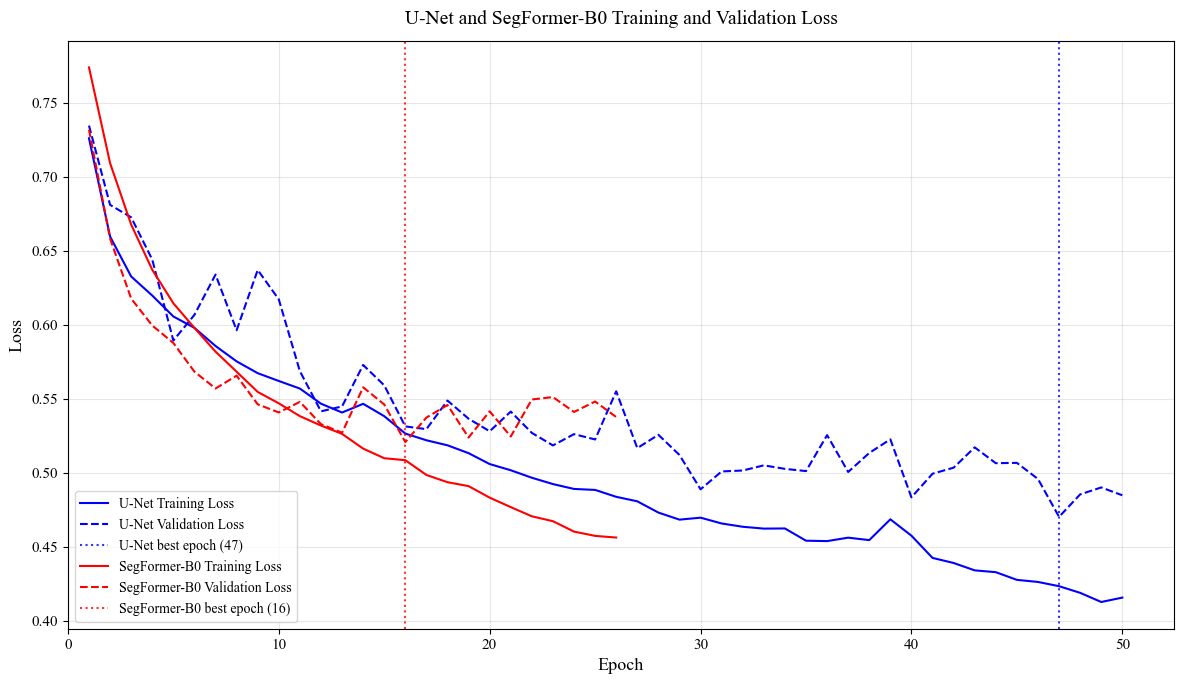

PDF saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/pdf/model_training_validation_loss.pdf
PNG saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/model_training_validation_loss.png


In [27]:
# Combined U-Net and SegFormer training history:

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

unet_epochs = range(1, len(unet_history["train_loss"]) + 1)
segformer_epochs = range(1, len(segformer_history["train_loss"]) + 1)
fig, ax = plt.subplots(figsize=(12, 7))

# U-Net in blue
ax.plot(
    unet_epochs,
    unet_history["train_loss"],
    color="blue",
    linestyle="-",
    label="U-Net Training Loss")
ax.plot(
    unet_epochs,
    unet_history["val_loss"],
    color="blue",
    linestyle="--",
    label="U-Net Validation Loss")
ax.axvline(
    unet_checkpoint["best_epoch"],
    color="blue",
    linestyle=":",
    alpha=0.8,
    label=f"U-Net best epoch ({unet_checkpoint['best_epoch']})")

# SegFormer-B0 in red
ax.plot(
    segformer_epochs,
    segformer_history["train_loss"],
    color="red",
    linestyle="-",
    label="SegFormer-B0 Training Loss")
ax.plot(
    segformer_epochs,
    segformer_history["val_loss"],
    color="red",
    linestyle="--",
    label="SegFormer-B0 Validation Loss")
ax.axvline(
    segformer_checkpoint["best_epoch"],
    color="red",
    linestyle=":",
    alpha=0.8,
    label=f"SegFormer-B0 best epoch "
          f"({segformer_checkpoint['best_epoch']})")

ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Loss", fontsize=13)
ax.set_title(
    "U-Net and SegFormer-B0 Training and Validation Loss",
    fontsize=14,
    fontweight="normal",
    pad=12)
ax.tick_params(axis="both", labelsize=11)
ax.legend(
    loc="lower left",
    fontsize=10,
    frameon=True)
ax.set_xlim(left=0)

ax.grid(alpha=0.3)
plt.tight_layout()

pdf_path = PDF_DIR / "model_training_validation_loss.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")

png_path = FIGURES_DIR / "model_training_validation_loss.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")
plt.show()

print(f"PDF saved to: {pdf_path}")
print(f"PNG saved to: {png_path}")

--------------------
###### 2
## Section 2: NaN Audit & Handelling
###### 2.1
### Section 2.1 - NaN Audit

In [13]:
# Auditing the undefined metric values:

metric_columns = [
    "IoU",
    "F1",
    "Precision",
    "Recall"]

for model_name in ["U-Net", "SegFormer-B0"]:

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    model_results = principal_test_results[principal_test_results["model"] == model_name].copy()

    for metric in metric_columns:

        missing = model_results[model_results[metric].isna()]

        print(f"\n{metric} undefined: {len(missing)} scenes")

        if len(missing) > 0:

            display(
                missing[
                    [
                        "scene_id",
                        "flood_event",
                        "flood_extent",
                        "TP",
                        "FP",
                        "TN",
                        "FN"
                    ]
                ]
            )


U-Net

IoU undefined: 2 scenes


,scene_id,flood_event,flood_extent,TP,FP,TN,FN
7,Ghana_53713,Ghana,0.0,0,0,262144,0
8,Ghana_167233,Ghana,0.0,0,0,262144,0



F1 undefined: 2 scenes


,scene_id,flood_event,flood_extent,TP,FP,TN,FN
7,Ghana_53713,Ghana,0.0,0,0,262144,0
8,Ghana_167233,Ghana,0.0,0,0,262144,0



Precision undefined: 4 scenes


...

,scene_id,flood_event,flood_extent,TP,FP,TN,FN
94,Ghana_53713,Ghana,0.0,0,0,262144,0
95,Ghana_167233,Ghana,0.0,0,0,262144,0



Precision undefined: 4 scenes


,scene_id,flood_event,flood_extent,TP,FP,TN,FN
88,Ghana_1078550,Ghana,0.536728,0,0,260737,1407
94,Ghana_53713,Ghana,0.000000,0,0,262144,0
95,Ghana_167233,Ghana,0.000000,0,0,262144,0
154,Sri-Lanka_534068,Sri-Lanka,0.447845,0,0,260970,1174



Recall undefined: 6 scenes


,scene_id,flood_event,flood_extent,TP,FP,TN,FN
89,Ghana_97059,Ghana,0.0,0,251,27143,0
94,Ghana_53713,Ghana,0.0,0,0,262144,0
95,Ghana_167233,Ghana,0.0,0,0,262144,0
104,India_44475,India,0.0,0,6,260169,0
125,Pakistan_528249,Pakistan,0.0,0,257,76725,0
132,Paraguay_40936,Paraguay,0.0,0,24025,191306,0


In [14]:
# Identify why metrics are undefined:

def explain_undefined_metric(row):
    """
    Function to Identify the mathematical reason a segmentation
    metric may be undefined for a scene.
    """

    reasons = []

    tp = row["TP"]
    fp = row["FP"]
    fn = row["FN"]

    if tp + fp + fn == 0:reasons.append("No ground-truth or predicted positive pixels")
    if tp + fp == 0:reasons.append("No predicted positive pixels")
    if tp + fn == 0:reasons.append("No ground-truth positive pixels")

    return "; ".join(reasons)


undefined_rows = principal_test_results[principal_test_results[metric_columns].isna().any(axis=1)].copy()
undefined_rows["undefined_reason"] = (undefined_rows.apply(explain_undefined_metric,axis=1))

display(
    undefined_rows[
        [
            "scene_id",
            "model",
            "flood_extent",
            "TP",
            "FP",
            "FN",
            "undefined_reason"
        ]
    ]
)

,scene_id,model,flood_extent,TP,FP,FN,undefined_reason
2,Ghana_97059,U-Net,0.000000,0,322,0,No ground-truth positive pixels
7,Ghana_53713,U-Net,0.000000,0,0,0,No ground-truth or predicted positive pixels; ...
8,Ghana_167233,U-Net,0.000000,0,0,0,No ground-truth or predicted positive pixels; ...
9,Ghana_141271,U-Net,0.624084,0,0,1636,No predicted positive pixels
17,India_44475,U-Net,0.000000,0,12,0,No ground-truth positive pixels
38,Pakistan_528249,U-Net,0.000000,0,474,0,No ground-truth positive pixels
45,Paraguay_40936,U-Net,0.000000,0,107,0,No ground-truth positive pixels
51,Paraguay_80102,U-Net,0.008392,0,0,22,No predicted positive pixels
88,Ghana_1078550,SegFormer-B0,0.536728,0,0,1407,No predicted positive pixels
89,Ghana_97059,SegFormer-B0,0.000000,0,251,0,No ground-truth positive pixels


In [15]:
# Metric-specific analysis datasets:

iou_data = (
    principal_test_results[
        [
            "scene_id",
            "flood_event",
            "model",
            "flood_extent",
            "IoU"
        ]
    ]
    .dropna(subset=["flood_extent", "IoU"])
    .copy()
)

f1_data = (
    principal_test_results[
        [
            "scene_id",
            "flood_event",
            "model",
            "flood_extent",
            "F1"
        ]
    ]
    .dropna(subset=["flood_extent", "F1"])
    .copy()
)

precision_data = (
    principal_test_results[
        [
            "scene_id",
            "flood_event",
            "model",
            "flood_extent",
            "Precision"
        ]
    ]
    .dropna(
        subset=["flood_extent", "Precision"]
    )
    .copy()
)

recall_data = (
    principal_test_results[
        [
            "scene_id",
            "flood_event",
            "model",
            "flood_extent",
            "Recall"
        ]
    ]
    .dropna(
        subset=["flood_extent", "Recall"]
    )
    .copy()
)

In [16]:
# Effective sample sizes for statistical analysis:

analysis_datasets = {
    "IoU": iou_data,
    "F1": f1_data,
    "Precision": precision_data,
    "Recall": recall_data}

for metric, data in analysis_datasets.items():

    print(f"\n{metric}")

    for model_name in [
        "U-Net",
        "SegFormer-B0"
    ]:

        n = len(data[data["model"] == model_name])

        print(f"  {model_name}: n = {n}")


IoU
  U-Net: n = 85
  SegFormer-B0: n = 85

F1
  U-Net: n = 85
  SegFormer-B0: n = 85

Precision
  U-Net: n = 83
  SegFormer-B0: n = 83

Recall
  U-Net: n = 81
  SegFormer-B0: n = 81


Metric values that were mathematically undefined for individual scenes were retained as missing observations rather than assigned arbitrary numerical values. For each correlation and regression analysis, only scenes with valid values for the corresponding performance measure were included, and the resulting effective sample size was reported.

-------------------
###### 3
## Section 3: descriptive analyses
###### 3.1
### Section 3.1 - flood extent Descriptive statistics

In [17]:
# Descriptive Analysis of Flood Extent scene-level data:

# Flood extent is identical for both models, so keep one row per scene.
principal_extent = (principal_test_results[["scene_id", "flood_event", "flood_extent"]].drop_duplicates(subset="scene_id").copy())
bolivia_extent = (bolivia_results[["scene_id", "flood_event", "flood_extent"]].drop_duplicates(subset="scene_id").copy())

print("Principal test scenes:", len(principal_extent))
print("Bolivia holdout scenes:", len(bolivia_extent))

principal_extent.head()

Principal test scenes: 87
Bolivia holdout scenes: 14


,scene_id,flood_event,flood_extent
0,Ghana_313799,Ghana,6.108466
1,Ghana_1078550,Ghana,0.536728
2,Ghana_97059,Ghana,0.000000
3,Ghana_359826,Ghana,1.333618
4,Ghana_319168,Ghana,23.027665


In [19]:
# Flood extent summary statistics:

extent_summary = pd.DataFrame({
    "n": [principal_extent["flood_extent"].count()],
    "mean": [principal_extent["flood_extent"].mean()],
    "median": [principal_extent["flood_extent"].median()],
    "std": [principal_extent["flood_extent"].std()],
    "min": [principal_extent["flood_extent"].min()],
    "Q1": [principal_extent["flood_extent"].quantile(0.25)],
    "Q3": [principal_extent["flood_extent"].quantile(0.75)],
    "max": [principal_extent["flood_extent"].max()],})

extent_summary["IQR"] = extent_summary["Q3"] - extent_summary["Q1"]
display(extent_summary.round(3))
# save:
extent_summary.to_csv(RESULTS_TABLE_DIR / "flood_extent_summary.csv", index=False)

print("Saved:", RESULTS_TABLE_DIR / "flood_extent_summary.csv")


,n,mean,median,std,min,Q1,Q3,max,IQR
0,87,7.958,1.619,14.889,0.0,0.505,6.174,66.828,5.669


Saved: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/tables/flood_extent_summary.csv


In [20]:
# Flood extent distribution categories:

extent_categories = pd.Series({"Zero extent (0%)":(principal_extent["flood_extent"] == 0).sum(),

    "Very low extent (0–1%)":
        ((principal_extent["flood_extent"] > 0) &
         (principal_extent["flood_extent"] < 1)).sum(),

    "Low extent (1–5%)":
        ((principal_extent["flood_extent"] >= 1) &
         (principal_extent["flood_extent"] < 5)).sum(),

    "Moderate extent (5–25%)":
        ((principal_extent["flood_extent"] >= 5) &
         (principal_extent["flood_extent"] < 25)).sum(),

    "High extent (25–50%)":
        ((principal_extent["flood_extent"] >= 25) &
         (principal_extent["flood_extent"] < 50)).sum(),

    "Very high extent (>=50%)":
        (principal_extent["flood_extent"] >= 50).sum()})

display(extent_categories.to_frame("n_scenes"))

extent_category_percent = (extent_categories / len(principal_extent) * 100).round(1)
display(extent_category_percent.to_frame("percent"))


extent_categories.to_frame("n_scenes").to_csv(RESULTS_TABLE_DIR / "flood_extent_categories_counts.csv")
extent_category_percent.to_frame("percent").to_csv(RESULTS_TABLE_DIR / "flood_extent_categories_percent.csv")


,n_scenes
Zero extent (0%),6
Very low extent (0–1%),30
Low extent (1–5%),25
Moderate extent (5–25%),16
High extent (25–50%),7
Very high extent (>=50%),3


,percent
Zero extent (0%),6.9
Very low extent (0–1%),34.5
Low extent (1–5%),28.7
Moderate extent (5–25%),18.4
High extent (25–50%),8.0
Very high extent (>=50%),3.4


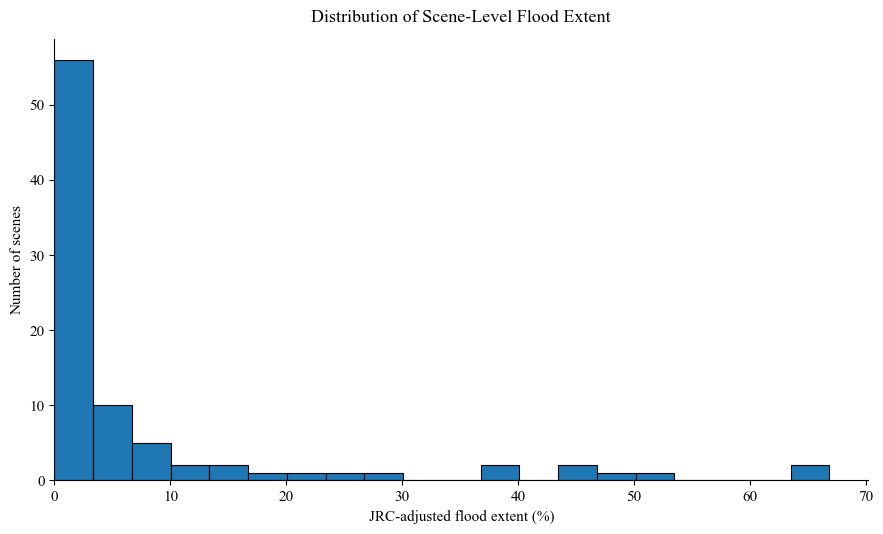

In [22]:
# Visualising the distribution of flood extent

# Set dissertation-style font
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(
    principal_extent["flood_extent"],
    bins=20,
    edgecolor="black",
    linewidth=0.8)

# Axis labels and title
ax.set_xlabel(
    "JRC-adjusted flood extent (%)",
    fontsize=11)
ax.set_ylabel(
    "Number of scenes",
    fontsize=11)
ax.set_title(
    "Distribution of Scene-Level Flood Extent",
    fontsize=13,
    fontweight="normal",
    pad=12)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
# Improves axis appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(
    axis="both",
    labelsize=11)

# Clean layout
plt.tight_layout()

pdf_path = PDF_DIR / "flood_extent_distribution.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")

png_path = FIGURES_DIR / "flood_extent_distribution.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")

plt.show()

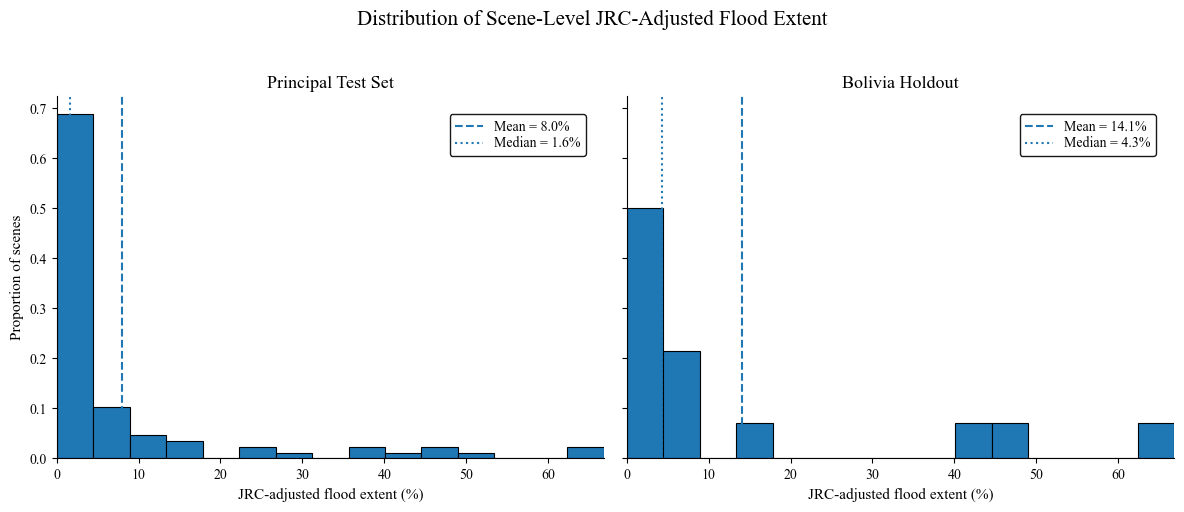

In [28]:
# Combined flood extent distribution figure - Principal Test vs Bolivia Holdout

plt.rcParams["font.family"] = "Times New Roman"

# identical bins and x-axis for direct comparison
max_extent = max(
    principal_extent["flood_extent"].max(),
    bolivia_extent["flood_extent"].max())

bins = np.linspace(0, max_extent, 16)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True)

# Principal Test
axes[0].hist(
    principal_extent["flood_extent"].dropna(),
    bins=bins,
    weights=np.ones(
        principal_extent["flood_extent"].dropna().shape[0]
    ) / len(principal_extent),
    edgecolor="black",
    linewidth=0.8)

principal_mean = principal_extent["flood_extent"].mean()
principal_median = principal_extent["flood_extent"].median()

axes[0].axvline(
    principal_mean,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {principal_mean:.1f}%")

axes[0].axvline(
    principal_median,
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {principal_median:.1f}%")

axes[0].set_title(
    "Principal Test Set",
    fontsize=13,
    fontweight="normal",
    fontname="Times New Roman")

axes[0].set_xlabel(
    "JRC-adjusted flood extent (%)",
    fontsize=11,
    fontname="Times New Roman")

axes[0].set_ylabel(
    "Proportion of scenes",
    fontsize=11,
    fontname="Times New Roman")

axes[0].legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.97),
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    edgecolor="black",
    facecolor="white",
    borderpad=0.4,
    labelspacing=0.2,
    handlelength=2,
    prop={"family": "Times New Roman", "size": 10})

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.3)


# Bolivia Holdout
axes[1].hist(
    bolivia_extent["flood_extent"].dropna(),
    bins=bins,
    weights=np.ones(
        bolivia_extent["flood_extent"].dropna().shape[0]
    ) / len(bolivia_extent),
    edgecolor="black",
    linewidth=0.8)

bolivia_mean = bolivia_extent["flood_extent"].mean()
bolivia_median = bolivia_extent["flood_extent"].median()

axes[1].axvline(
    bolivia_mean,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {bolivia_mean:.1f}%")

axes[1].axvline(
    bolivia_median,
    linestyle=":",
    linewidth=1.5,
    label=f"Median = {bolivia_median:.1f}%")

axes[1].set_title(
    "Bolivia Holdout",
    fontsize=13,
    fontweight="normal",
    fontname="Times New Roman")

axes[1].set_xlabel(
    "JRC-adjusted flood extent (%)",
    fontsize=11,
    fontname="Times New Roman")

axes[1].legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.97),
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    edgecolor="black",
    facecolor="white",
    borderpad=0.4,
    labelspacing=0.2,
    handlelength=2,
    prop={"family": "Times New Roman", "size": 10})

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.3)

fig.suptitle(
    "Distribution of Scene-Level JRC-Adjusted Flood Extent",
    fontsize=15,
    fontweight="normal",
    fontname="Times New Roman",
    y=1.02)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_fontname("Times New Roman")
        label.set_fontsize(10)

    for label in ax.get_yticklabels():
        label.set_fontname("Times New Roman")
        label.set_fontsize(10)

# Dissertation-style axis formatting
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.margins(x=0)

for ax in axes:
    ax.grid(False, axis="y")


plt.tight_layout()

pdf_path = PDF_DIR / "Combined_flood_extent_distribution.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")

png_path = FIGURES_DIR / "Combined_flood_extent_distribution.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")

plt.show()

In [29]:
# Principal test vs Bolivia flood extent:

extent_comparison = pd.DataFrame({
    "Principal Test": principal_extent["flood_extent"].describe(),
    "Bolivia Holdout": bolivia_extent["flood_extent"].describe()})

display(extent_comparison.round(3))

extent_comparison.to_csv(RESULTS_TABLE_DIR / "flood_extent_evaluation_set_comparison.csv")


,Principal Test,Bolivia Holdout
count,87.000,14.000
mean,7.958,14.073
std,14.889,20.907
min,0.000,0.001
25%,0.505,0.721
50%,1.619,4.316
75%,6.174,13.911
max,66.828,64.188


/var/folders/xh/8m4bc5md4rb_gzhj0jcjvbj40000gn/T/ipykernel_10223/3058806982.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


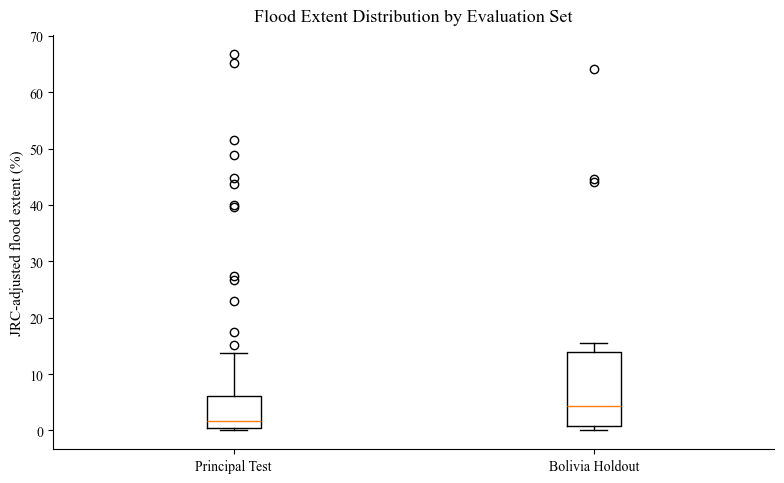

PDF saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/pdf/flood_extent_evaluation_set_boxplot.pdf
PNG saved to: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/flood_extent_evaluation_set_boxplot.png


In [30]:
# Flood extent comparison
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [
        principal_extent["flood_extent"].dropna(),
        bolivia_extent["flood_extent"].dropna()
    ],
    labels=["Principal Test", "Bolivia Holdout"])
ax.set_ylabel(
    "JRC-adjusted flood extent (%)",
    fontsize=11,
    fontname="Times New Roman")

ax.set_title(
    "Flood Extent Distribution by Evaluation Set",
    fontsize=13,
    fontweight="normal",
    fontname="Times New Roman",
    pad=10)

ax.tick_params(
    axis="both",
    labelsize=10)

for label in ax.get_xticklabels():
    label.set_fontname("Times New Roman")
    label.set_fontsize(10)

for label in ax.get_yticklabels():
    label.set_fontname("Times New Roman")
    label.set_fontsize(10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

pdf_path = PDF_DIR / "flood_extent_evaluation_set_boxplot.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")

png_path = FIGURES_DIR / "flood_extent_evaluation_set_boxplot.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")

plt.show()

print(f"PDF saved to: {pdf_path}")
print(f"PNG saved to: {png_path}")

--------------------
###### 3.2
### Section 3.2 - Flood Extent vs Segmentation Performance Analysis

In [31]:
# Imports and prepare analysis data:

from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

# Copy the principal test results
analysis_data = principal_test_results.copy()

print("Rows:", len(analysis_data))
print("Models:", analysis_data["model"].unique())
print("Metrics:", ["IoU", "F1", "Precision", "Recall"])

Rows: 174
Models: ['U-Net' 'SegFormer-B0']
Metrics: ['IoU', 'F1', 'Precision', 'Recall']


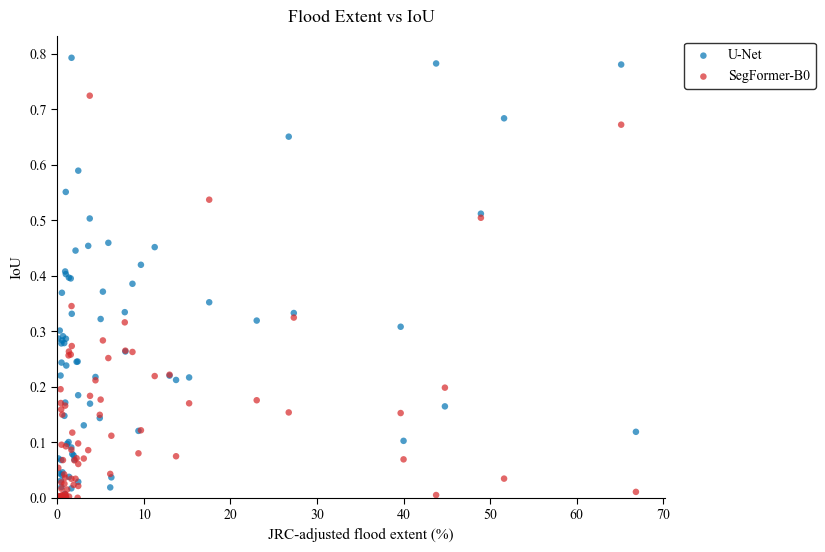

In [32]:
# Flood extent vs IoU:

plt.rcParams["font.family"] = "Times New Roman"
fig, ax = plt.subplots(figsize=(9, 6))
model_colours = {
    "U-Net": "#0072B2",
    "SegFormer-B0": "#D62728"}

for model in analysis_data["model"].unique():

    subset = analysis_data[
        (analysis_data["model"] == model) &
        (analysis_data["IoU"].notna())]

    ax.scatter(
        subset["flood_extent"],
        subset["IoU"],
        s=22,
        alpha=0.70,
        color=model_colours.get(model, "#555555"),
        label=model,
        edgecolors="none")

# Axis labels
ax.set_xlabel(
    "JRC-adjusted flood extent (%)",
    fontsize=11,
    fontname="Times New Roman")
ax.set_ylabel(
    "IoU",
    fontsize=11,
    fontname="Times New Roman")
ax.set_title(
    "Flood Extent vs IoU",
    fontsize=13,
    fontweight="normal",
    fontname="Times New Roman",
    pad=10)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.tick_params(
    axis="both",
    labelsize=10,
    direction="out",
    length=4,
    width=0.8)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Times New Roman")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
    edgecolor="black",
    facecolor="white",
    prop={
        "family": "Times New Roman",
        "size": 10
    }
)
plt.subplots_adjust(right=0.80)

pdf_path = PDF_DIR / "flood_extent_vs_iou.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")

png_path = FIGURES_DIR / "flood_extent_vs_iou.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")

plt.show()

In [33]:
# Pearson correlation analysis Table:

correlation_results = []
metrics = ["IoU", "F1", "Precision", "Recall"]

for model in analysis_data["model"].unique():

    for metric in metrics:

        subset = analysis_data[
            (analysis_data["model"] == model) &
            (analysis_data["flood_extent"].notna()) &
            (analysis_data[metric].notna())].copy()

        x = subset["flood_extent"]
        y = subset[metric]
        r, p = pearsonr(x, y)

        correlation_results.append({
            "model": model,
            "metric": metric,
            "n": len(subset),
            "pearson_r": r,
            "p_value": p})

correlation_results = pd.DataFrame(correlation_results)
display(correlation_results.round(4))

,model,metric,n,pearson_r,p_value
0,U-Net,IoU,85,0.4154,0.0001
1,U-Net,F1,85,0.3815,0.0003
2,U-Net,Precision,83,0.3588,0.0009
3,U-Net,Recall,81,0.2090,0.0611
4,SegFormer-B0,IoU,85,0.3454,0.0012
5,SegFormer-B0,F1,85,0.3263,0.0023
6,SegFormer-B0,Precision,83,0.4862,0.0000
7,SegFormer-B0,Recall,81,0.2248,0.0436


In [34]:
# correlation interpretation:

def correlation_strength(r):
    """Describes the absolute magnitude of a Pearson correlation."""
    
    r_abs = abs(r)

    if r_abs < 0.20:
        return "very weak"
    elif r_abs < 0.40:
        return "weak"
    elif r_abs < 0.60:
        return "moderate"
    elif r_abs < 0.80:
        return "strong"
    else:
        return "very strong"

correlation_results["direction"] = np.where( correlation_results["pearson_r"] >= 0, "positive", "negative")
correlation_results["strength"] = (correlation_results["pearson_r"].apply(correlation_strength))
display(correlation_results.round(4))

correlation_results.to_csv(RESULTS_TABLE_DIR / "pearson_correlation_results.csv", index=False)


,model,metric,n,pearson_r,p_value,direction,strength
0,U-Net,IoU,85,0.4154,0.0001,positive,moderate
1,U-Net,F1,85,0.3815,0.0003,positive,weak
2,U-Net,Precision,83,0.3588,0.0009,positive,weak
3,U-Net,Recall,81,0.2090,0.0611,positive,weak
4,SegFormer-B0,IoU,85,0.3454,0.0012,positive,weak
5,SegFormer-B0,F1,85,0.3263,0.0023,positive,weak
6,SegFormer-B0,Precision,83,0.4862,0.0000,positive,moderate
7,SegFormer-B0,Recall,81,0.2248,0.0436,positive,weak


In [35]:
# Simple linear regression:

regression_results = []

for model in analysis_data["model"].unique():

    for metric in metrics:

        subset = analysis_data[
            (analysis_data["model"] == model) &
            (analysis_data["flood_extent"].notna()) &
            (analysis_data[metric].notna())].copy()

        X = sm.add_constant(subset["flood_extent"])
        y = subset[metric]
        model_fit = sm.OLS(y, X).fit()

        regression_results.append({
            "model": model,
            "metric": metric,
            "n": len(subset),
            "intercept": model_fit.params["const"],
            "slope": model_fit.params["flood_extent"],
            "r_squared": model_fit.rsquared,
            "slope_p_value": model_fit.pvalues["flood_extent"],
            "slope_ci_lower": model_fit.conf_int().loc["flood_extent", 0],
            "slope_ci_upper": model_fit.conf_int().loc["flood_extent", 1]})

regression_results = pd.DataFrame(regression_results)
display(regression_results.round(4))

regression_results.to_csv(RESULTS_TABLE_DIR / "linear_regression_results.csv", index=False)


,model,metric,n,intercept,slope,r_squared,slope_p_value,slope_ci_lower,slope_ci_upper
0,U-Net,IoU,85,0.1879,0.0056,0.1726,0.0001,0.0029,0.0083
1,U-Net,F1,85,0.2863,0.0064,0.1455,0.0003,0.0030,0.0098
2,U-Net,Precision,83,0.4239,0.0074,0.1287,0.0009,0.0031,0.0116
3,U-Net,Recall,81,0.3753,0.0041,0.0437,0.0611,-0.0002,0.0083
4,SegFormer-B0,IoU,85,0.0926,0.0034,0.1193,0.0012,0.0014,0.0054
5,SegFormer-B0,F1,85,0.1539,0.0043,0.1065,0.0023,0.0016,0.0071
6,SegFormer-B0,Precision,83,0.2382,0.0105,0.2364,0.0000,0.0063,0.0147
7,SegFormer-B0,Recall,81,0.1708,0.0032,0.0506,0.0436,0.0001,0.0063


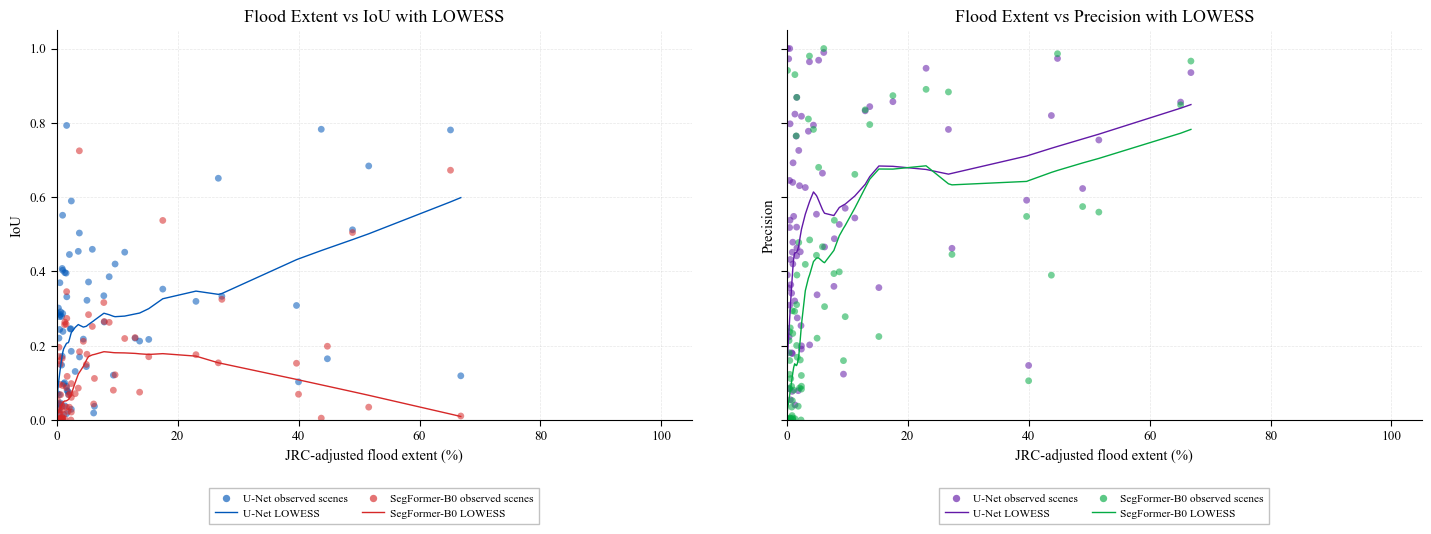

In [36]:
# Flood Extent vs IoU and Precision with LOWESS Figure:

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "normal",
    "axes.labelsize": 10.5,
    "axes.labelweight": "normal",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 8.2,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,})

# IoU colours
iou_unet_colour = "#0057B8"             # blue
iou_segformer_colour = "#D62828"        # red
# Precision colours
precision_unet_colour = "#6219A7"       # purple
precision_segformer_colour = "#04AB44"  # green

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

def plot_metric(
    ax,
    metric,
    unet_colour,
    segformer_colour,
    title):
    """
    Plot scene-level observations and LOWESS curves
    for U-Net and SegFormer-B0.
    """
    for model, colour in [
        ("U-Net", unet_colour), ("SegFormer-B0", segformer_colour)]:

        subset = analysis_data[
            (analysis_data["model"] == model) &
            (analysis_data[metric].notna()) &
            (analysis_data["flood_extent"].notna())].copy()

        x = subset["flood_extent"].to_numpy()
        y = subset[metric].to_numpy()

        ax.scatter(x, y, s=24, alpha=0.55, color=colour, edgecolors="none")
        #LOWESS Smooth
        lowess_result = lowess(y,x,
            frac=0.60, return_sorted=True)
        ax.plot(lowess_result[:, 0], lowess_result[:, 1],
            color=colour, linewidth=1.0)

    ax.set_xlim(0, 105)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_xlabel("JRC-adjusted flood extent (%)")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", which="major",
        direction="out", length=4)
    ax.grid(which="major", axis="both",
        linestyle="--", linewidth=0.5, alpha=0.30)
    ax.set_axisbelow(True)

#IoU
plot_metric(axes[0],
    metric="IoU",
    unet_colour=iou_unet_colour,
    segformer_colour=iou_segformer_colour,
    title="Flood Extent vs IoU with LOWESS")
axes[0].set_ylabel("IoU")

# Precision
plot_metric(
    axes[1],
    metric="Precision",
    unet_colour=precision_unet_colour,
    segformer_colour=precision_segformer_colour,
    title="Flood Extent vs Precision with LOWESS")
axes[1].set_ylabel("Precision")

#legends
def create_legend_handles(unet_colour, segformer_colour):

    return [
        # U-Net obs
        plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=unet_colour,
            markeredgecolor="none",
            markersize=5.3,
            alpha=0.65,
            label="U-Net observed scenes"),

        # U-Net LOWESS
        plt.Line2D([0], [0],
            color=unet_colour,
            linewidth=1.0,
            label="U-Net LOWESS"),

        # SegFormer observations
        plt.Line2D([0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=segformer_colour,
            markeredgecolor="none",
            markersize=5.3,
            alpha=0.65,
            label="SegFormer-B0 observed scenes"),

        # SegFormer LOWESS
        plt.Line2D([0], [0],
            color=segformer_colour,
            linewidth=1.0,
            label="SegFormer-B0 LOWESS")
    ]

#legend IoU
axes[0].legend(
    handles=create_legend_handles(
        iou_unet_colour,
        iou_segformer_colour),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor="0.75",
    borderpad=0.5,
    handlelength=2.0,
    handletextpad=0.5,
    labelspacing=0.4,
    columnspacing=1.2)

# Legend Precision
axes[1].legend(
    handles=create_legend_handles(
        precision_unet_colour,
        precision_segformer_colour),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor="0.75",
    borderpad=0.5,
    handlelength=2.0,
    handletextpad=0.5,
    labelspacing=0.4,
    columnspacing=1.2)

# making layout
plt.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.23,
    top=0.88,
    wspace=0.15)

# saves
pdf_path = PDF_DIR / "flood_extent_iou_precision_lowess_joint.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")

png_path = FIGURES_DIR / "flood_extent_iou_precision_lowess_joint.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")

plt.show()

--------------------
###### 3.3
### Section 3.3 - Regression diagnostics

In [39]:
# Fitting regressions and calculating the diagnostics:

from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

metrics = ["IoU", "F1", "Precision", "Recall"]

diagnostic_models = {}
diagnostic_rows = []

for model_name in analysis_data["model"].unique():

    for metric in metrics:

        subset = analysis_data[
            (analysis_data["model"] == model_name) &
            (analysis_data["flood_extent"].notna()) &
            (analysis_data[metric].notna())].copy()

        X = sm.add_constant(subset["flood_extent"])
        y = subset[metric]
        fit = sm.OLS(y, X).fit()

        # influence statistics
        influence = fit.get_influence()
        fitted = fit.fittedvalues
        residuals = fit.resid

        standardized_residuals = influence.resid_studentized_internal
        studentized_residuals = influence.resid_studentized_external
        leverage = influence.hat_matrix_diag
        cooks_distance = influence.cooks_distance[0]

        # Breusch-Pagan test for heteroskedasticity
        bp = het_breuschpagan(residuals, fit.model.exog)
        bp_lm_stat = bp[0]
        bp_lm_p = bp[1]
        bp_f_stat = bp[2]
        bp_f_p = bp[3]

        # Omnibus normality test
        normality_stat, normality_p = stats.normaltest(residuals)

        diagnostic_models[(model_name, metric)] = {
            "data": subset,
            "fit": fit,
            "fitted": fitted,
            "residuals": residuals,
            "standardized_residuals": standardized_residuals,
            "studentized_residuals": studentized_residuals,
            "leverage": leverage,
            "cooks_distance": cooks_distance}
        n = len(subset)

        # diagnostic thresholds (common ones)
        cooks_threshold = 4 / n
        leverage_threshold = 2 * 2 / n
        max_cook_idx = np.argmax(cooks_distance)
        max_leverage_idx = np.argmax(leverage)

        diagnostic_rows.append({
            "model": model_name,
            "metric": metric,
            "n": n,

            "Breusch_Pagan_p": bp_f_p,
            "Normality_p": normality_p,

            "max_abs_standardized_residual": np.max(np.abs(standardized_residuals)),

            "max_leverage": np.max(leverage),

            "max_cooks_distance": np.max(cooks_distance),

            "cooks_threshold": cooks_threshold,

            "leverage_threshold":leverage_threshold,

            "max_cooks_scene": subset.iloc[max_cook_idx]["scene_id"],

            "max_leverage_scene": subset.iloc[max_leverage_idx]["scene_id"],

            "max_cooks_flood_extent": subset.iloc[max_cook_idx]["flood_extent"],

            "max_leverage_flood_extent": subset.iloc[max_leverage_idx]["flood_extent"]})

diagnostics_summary = pd.DataFrame(diagnostic_rows)
display(diagnostics_summary.round(4))
#save:
diagnostics_summary.to_csv(RESULTS_TABLE_DIR / "regression_diagnostics_summary.csv",index=False)


,model,metric,n,Breusch_Pagan_p,Normality_p,max_abs_standardized_residual,max_leverage,max_cooks_distance,cooks_threshold,leverage_threshold,max_cooks_scene,max_leverage_scene,max_cooks_flood_extent,max_leverage_flood_extent
0,U-Net,IoU,85,0.0194,0.1291,3.2198,0.1936,0.8513,0.0471,0.0471,Pakistan_849790,Pakistan_849790,66.8281,66.8281
1,U-Net,F1,85,0.2888,0.0164,2.5231,0.1936,0.6822,0.0471,0.0471,Pakistan_849790,Pakistan_849790,66.8281,66.8281
2,U-Net,Precision,83,0.0917,0.0502,2.0227,0.1940,0.1430,0.0482,0.0482,Ghana_866994,Pakistan_849790,39.9894,66.8281
3,U-Net,Recall,81,0.5380,0.0000,2.0071,0.1944,0.4861,0.0494,0.0494,Pakistan_849790,Pakistan_849790,66.8281,66.8281
4,SegFormer-B0,IoU,85,0.0064,0.0000,4.4707,0.1936,0.9081,0.0471,0.0471,Mekong_1443339,Pakistan_849790,65.1260,66.8281
5,SegFormer-B0,F1,85,0.0032,0.0022,3.5626,0.1936,0.7395,0.0471,0.0471,Pakistan_849790,Pakistan_849790,66.8281,66.8281
6,SegFormer-B0,Precision,83,0.9239,0.0022,2.4517,0.1939,0.1378,0.0482,0.0482,Ghana_866994,Pakistan_849790,39.9894,66.8281
7,SegFormer-B0,Recall,81,0.0230,0.0004,2.7636,0.1944,0.4641,0.0494,0.0494,Pakistan_849790,Pakistan_849790,66.8281,66.8281


In [142]:
# HC3 robost regression sensitivity and heteroskedasticity check:

hc3_results = []

for model_name in analysis_data["model"].unique():

    for metric in ["IoU", "F1", "Precision", "Recall"]:

        # Same complete-case dataset that has been used for the primary regression
        subset = analysis_data[
            (analysis_data["model"] == model_name) &
            (analysis_data["flood_extent"].notna()) &
            (analysis_data[metric].notna())
        ].copy()

        X = sm.add_constant(subset["flood_extent"])
        y = subset[metric]

        # The riginal OLS model
        ols_fit = sm.OLS(y, X).fit()

        # HC3 heteroskedasticity inference
        hc3_fit = ols_fit.get_robustcov_results(cov_type="HC3")

        # Position of flood-extent coefficient
        slope_position = list(ols_fit.params.index).index("flood_extent")

        # HC3 coefficient and confidence interval
        hc3_slope = hc3_fit.params[slope_position]
        hc3_p = hc3_fit.pvalues[slope_position]
        hc3_ci = hc3_fit.conf_int()[slope_position]

        hc3_results.append({
            "model": model_name,
            "metric": metric,
            "n": len(subset),
            "OLS_slope":ols_fit.params["flood_extent"],
            "OLS_p_value":ols_fit.pvalues["flood_extent"],
            "HC3_slope":hc3_slope,
            "HC3_p_value":hc3_p,
            "HC3_CI_lower":hc3_ci[0],
            "HC3_CI_upper":hc3_ci[1]
        })

hc3_results = pd.DataFrame(hc3_results)

display(hc3_results.round(4))

,model,metric,n,OLS_slope,OLS_p_value,HC3_slope,HC3_p_value,HC3_CI_lower,HC3_CI_upper
0,U-Net,IoU,85,0.0056,0.0001,0.0056,0.0182,0.0010,0.0103
1,U-Net,F1,85,0.0064,0.0003,0.0064,0.0119,0.0015,0.0114
2,U-Net,Precision,83,0.0074,0.0009,0.0074,0.0000,0.0042,0.0106
3,U-Net,Recall,81,0.0041,0.0611,0.0041,0.1642,-0.0017,0.0098
4,SegFormer-B0,IoU,85,0.0034,0.0012,0.0034,0.1074,-0.0008,0.0075
5,SegFormer-B0,F1,85,0.0043,0.0023,0.0043,0.0950,-0.0008,0.0094
6,SegFormer-B0,Precision,83,0.0105,0.0000,0.0105,0.0000,0.0069,0.0142
7,SegFormer-B0,Recall,81,0.0032,0.0436,0.0032,0.2372,-0.0021,0.0085


In [143]:
# Identifying potentially influential observations

from IPython.display import display, HTML

influential_rows = []

for (model_name, metric), results in diagnostic_models.items():

    subset = results["data"].copy()
    subset["standardized_residual"] = (results["standardized_residuals"])
    subset["studentized_residual"] = (results["studentized_residuals"])
    subset["leverage"] = results["leverage"]
    subset["cooks_distance"] = results["cooks_distance"]

    n = len(subset)

    cooks_threshold = 4 / n
    leverage_threshold = 4 / n

    influential = subset[
        (subset["standardized_residual"].abs() > 3) |
        (subset["cooks_distance"] > cooks_threshold) |
        (subset["leverage"] > leverage_threshold)].copy()
    influential["model"] = model_name
    influential["metric"] = metric
    influential_rows.append(influential)
influential_observations = pd.concat(influential_rows, ignore_index=True)

columns_to_show = [
    "model",
    "metric",
    "scene_id",
    "flood_extent",
    "standardized_residual",
    "leverage",
    "cooks_distance"]

html_table = influential_observations[columns_to_show].to_html(index=False)

display(HTML(f"""
        <div style="
            max-height: 600px;
            overflow: auto;
            border: 1px solid #cccccc;
            padding: 5px;
        ">
            {html_table}
        </div>
        """))

influential_observations.to_csv(RESULTS_TABLE_DIR / "influential_observations.csv", index=False)

model,metric,scene_id,flood_extent,standardized_residual,leverage,cooks_distance
U-Net,IoU,Ghana_866994,39.989448,-1.724213,0.065318,0.103878
U-Net,IoU,Ghana_406026,1.638794,3.219848,0.014001,0.073606
U-Net,IoU,India_747992,44.764525,-1.543023,0.082584,0.107162
U-Net,IoU,India_80221,48.921228,0.273985,0.099574,0.004151
U-Net,IoU,India_399883,39.654508,-0.572024,0.064198,0.011224
U-Net,IoU,Mekong_1443339,65.125985,1.341488,0.183235,0.201862
U-Net,IoU,Nigeria_812045,43.750369,1.947168,0.078715,0.161973
U-Net,IoU,Pakistan_849790,66.828125,-2.662718,0.193632,0.851265
U-Net,IoU,Spain_7387658,51.599080,1.168336,0.111486,0.085637
U-Net,F1,Ghana_866994,39.989448,-1.571846,0.065318,0.086330


In [43]:
# Looking at the extreme flood-extent observations:

extreme_extent = analysis_data[analysis_data["flood_extent"] >= 40].copy()

display(extreme_extent[
        ["scene_id", "flood_event", "model",
        "flood_extent", "IoU", "F1", "Precision", "Recall"]].sort_values("flood_extent", ascending=False).round(4))

,scene_id,flood_event,model,flood_extent,IoU,F1,Precision,Recall
34,Pakistan_849790,Pakistan,U-Net,66.8281,0.1189,0.2125,0.9352,0.1199
121,Pakistan_849790,Pakistan,SegFormer-B0,66.8281,0.0106,0.0211,0.9662,0.0106
26,Mekong_1443339,Mekong,U-Net,65.1260,0.7808,0.8769,0.8558,0.8990
113,Mekong_1443339,Mekong,SegFormer-B0,65.1260,0.6724,0.8041,0.8483,0.7643
64,Spain_7387658,Spain,U-Net,51.5991,0.6838,0.8122,0.7537,0.8806
151,Spain_7387658,Spain,SegFormer-B0,51.5991,0.0345,0.0667,0.5596,0.0355
18,India_80221,India,U-Net,48.9212,0.5120,0.6772,0.6231,0.7417
105,India_80221,India,SegFormer-B0,48.9212,0.5046,0.6707,0.5745,0.8057
12,India_747992,India,U-Net,44.7645,0.1647,0.2829,0.9733,0.1655
99,India_747992,India,SegFormer-B0,44.7645,0.1985,0.3312,0.9861,0.1990


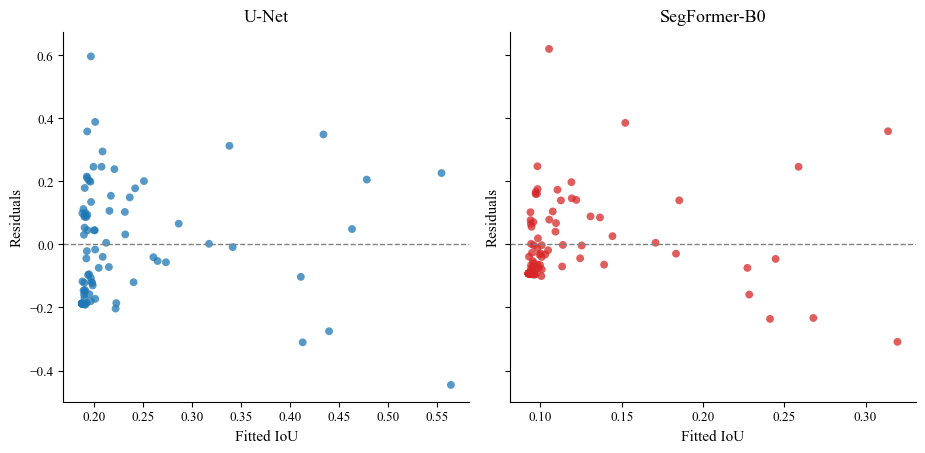

In [44]:
# IoU residuals vs fitted values plot:

# Consistent model colours for the dissertation
MODEL_COLORS = {"U-Net": "#1f77b4",          # blue
                "SegFormer-B0": "#d62728"    # red
}


plt.rcParams["font.family"] = "Times New Roman"
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)

for ax, model_name in zip(axes, ["U-Net", "SegFormer-B0"]):

    results = diagnostic_models[(model_name, "IoU")]

    # Residual points
    ax.scatter(
        results["fitted"],
        results["residuals"],
        color=MODEL_COLORS[model_name],
        alpha=0.75,
        s=32,
        edgecolors="none")

    # Zero reference line
    ax.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1.0)

    ax.set_xlabel(
        "Fitted IoU",
        fontsize=11)

    ax.set_ylabel(
        "Residuals",
        fontsize=11)

    ax.set_title(
        model_name,
        fontsize=13,
        fontweight="normal",
        pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.grid(False)

plt.subplots_adjust(wspace=0.10)

# saves
pdf_path = PDF_DIR / "iou_regression_residuals_publication.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")

png_path = FIGURES_DIR / "iou_regression_residuals_publication.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")

plt.show()

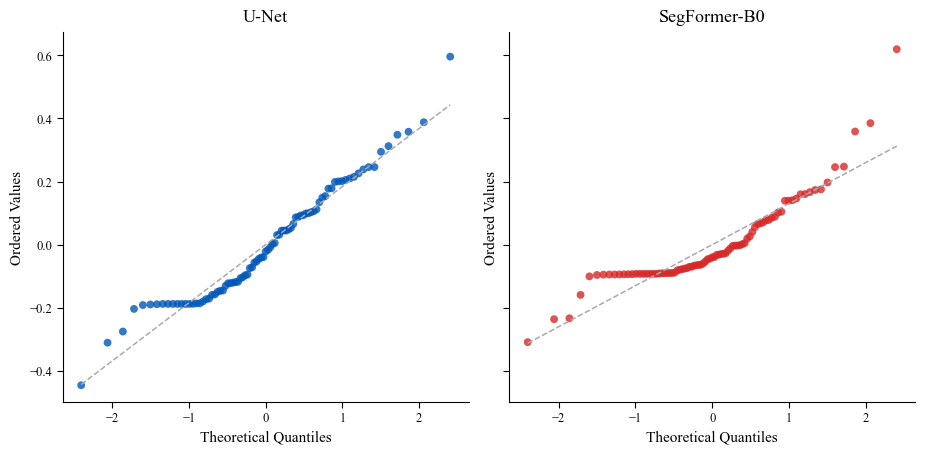

In [45]:
# IoU residual Q-Q plots:

MODEL_COLORS = {
    "U-Net": "#0057B8",          # stronger blue
    "SegFormer-B0": "#D62828"    # stronger red
}


plt.rcParams["font.family"] = "Times New Roman"
fig, axes = plt.subplots(1,2,figsize=(11, 4.8),sharey=True)

for ax, model_name in zip(axes, ["U-Net", "SegFormer-B0"]):

    results = diagnostic_models[(model_name, "IoU")]

    # doing plot manually to control the colour and style of the reference line
    (osm, osr), (slope, intercept, r) = stats.probplot(
        results["residuals"],
        dist="norm")

    # points
    ax.scatter(
        osm,
        osr,
        color=MODEL_COLORS[model_name],
        alpha=0.80,
        s=32,
        edgecolors="none")
    # reference line
    x_line = np.array([
        osm.min(),
        osm.max()])

    y_line = slope * x_line + intercept

    ax.plot(
        x_line,
        y_line,
        color="darkgrey",
        linestyle="--",
        linewidth=1.1)
    # labels
    ax.set_xlabel(
        "Theoretical Quantiles",
        fontsize=11)
    ax.set_ylabel(
        "Ordered Values",
        fontsize=11)
    # Title
    ax.set_title(
        model_name,
        fontsize=13,
        fontweight="normal",
        pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=0.8,
        labelsize=9)
    ax.grid(False)

# Reducing space between subplots
plt.subplots_adjust(wspace=0.10)

# save
pdf_path = PDF_DIR / "iou_regression_qqplots_publication.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")

png_path = FIGURES_DIR / "iou_regression_qqplots_publication.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")

plt.show()

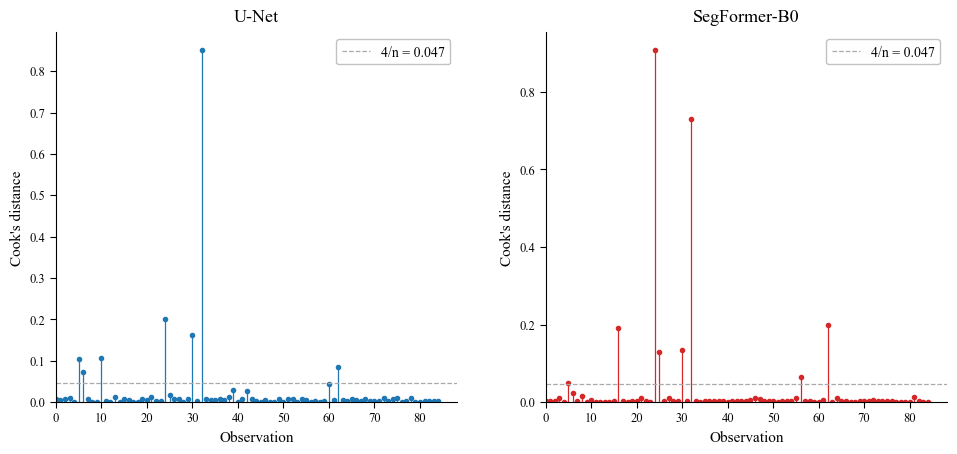

In [46]:
# Cook's distance for IoU plot:

MODEL_COLORS = {
    "U-Net": "#1f77b4",          # blue
    "SegFormer-B0": "#d62728"    # red
}

plt.rcParams["font.family"] = "Times New Roman"
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

for ax, model_name in zip(axes, ["U-Net", "SegFormer-B0"]):

    results = diagnostic_models[(model_name, "IoU")]
    subset = results["data"]
    cooks = results["cooks_distance"]

    n = len(subset)
    threshold = 4 / n

    # Cook's distance stems
    markerline, stemlines, baseline = ax.stem(
        np.arange(n),
        cooks,
        linefmt=MODEL_COLORS[model_name],
        markerfmt=MODEL_COLORS[model_name],
        basefmt=" ")
    plt.setp(stemlines, linewidth=0.9)
    plt.setp(markerline, markersize=3)

    # Influence threshold
    ax.axhline(
        threshold,
        color="darkgrey",
        linestyle="--",
        linewidth=0.9,
        label=f"4/n = {threshold:.3f}")


    ax.set_xlabel(
        "Observation",
        fontsize=11)
    ax.set_ylabel(
        "Cook's distance",
        fontsize=11)
    ax.set_title(
        model_name,
        fontsize=13,
        fontweight="normal",
        pad=8)

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=0.8,
        labelsize=9)
    ax.grid(False)

    ax.legend(
        fontsize=10,
        frameon=True,
        edgecolor="0.7",
        loc="upper right")

# more space between panels
plt.subplots_adjust(wspace=0.22)

pdf_path = PDF_DIR / "iou_cooks_distance_publication.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")

png_path = FIGURES_DIR / "iou_cooks_distance_publication.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")

plt.show()

---------------
###### 3.4
### Section 3.4 - Sensitivity Analysis

In [47]:
# Sensitivity Analysis:
# (Comparing the full regression with the influential observation removed to compare)

sensitivity_results = []
sensitivity_metrics = ["IoU", "Precision"]

for model_name in analysis_data["model"].unique():

    for metric in sensitivity_metrics:

        # The Full dataset
        full_subset = analysis_data[
            (analysis_data["model"] == model_name) &
            (analysis_data["flood_extent"].notna()) &
            (analysis_data[metric].notna())].copy()

        X_full = sm.add_constant(full_subset["flood_extent"])
        y_full = full_subset[metric]
        full_fit = sm.OLS(y_full, X_full).fit()

        # most influential observation
        influence = full_fit.get_influence()
        cooks = influence.cooks_distance[0]
        max_cook_position = np.argmax(cooks)
        influential_scene = full_subset.iloc[max_cook_position]["scene_id"]
        influential_extent = full_subset.iloc[max_cook_position]["flood_extent"]

        # Second sensitivity dataset
        sensitivity_subset = full_subset[full_subset["scene_id"] != influential_scene].copy()
        X_sensitivity = sm.add_constant(sensitivity_subset["flood_extent"])
        y_sensitivity = sensitivity_subset[metric]
        sensitivity_fit = sm.OLS(y_sensitivity, X_sensitivity).fit()

        # Pearson correlation after excluding most influential obs.
        sensitivity_r, sensitivity_p = pearsonr(sensitivity_subset["flood_extent"],sensitivity_subset[metric])

        sensitivity_results.append({
            "model": model_name,
            "metric": metric,
            "excluded_scene": influential_scene,
            "excluded_flood_extent": influential_extent,
            "full_n": len(full_subset),
            "sensitivity_n": len(sensitivity_subset),
            "full_pearson_r": pearsonr(full_subset["flood_extent"], full_subset[metric])[0],

            "full_slope":
                full_fit.params["flood_extent"],
            "full_r_squared":
                full_fit.rsquared,
            "full_p_value":
                full_fit.pvalues["flood_extent"],
            "sensitivity_pearson_r":
                sensitivity_r,
            "sensitivity_slope":
                sensitivity_fit.params["flood_extent"],
            "sensitivity_r_squared":
                sensitivity_fit.rsquared,
            "sensitivity_p_value":
                sensitivity_fit.pvalues["flood_extent"]
        })

sensitivity_results = pd.DataFrame(sensitivity_results)
display(sensitivity_results.round(4))

,model,metric,excluded_scene,excluded_flood_extent,full_n,sensitivity_n,full_pearson_r,full_slope,full_r_squared,full_p_value,sensitivity_pearson_r,sensitivity_slope,sensitivity_r_squared,sensitivity_p_value
0,U-Net,IoU,Pakistan_849790,66.8281,85,84,0.4154,0.0056,0.1726,0.0001,0.4902,0.0073,0.2403,0.0000
1,U-Net,Precision,Ghana_866994,39.9894,83,82,0.3588,0.0074,0.1287,0.0009,0.4007,0.0084,0.1605,0.0002
2,SegFormer-B0,IoU,Mekong_1443339,65.1260,85,84,0.3454,0.0034,0.1193,0.0012,0.2104,0.0021,0.0443,0.0547
3,SegFormer-B0,Precision,Ghana_866994,39.9894,83,82,0.4862,0.0105,0.2364,0.0000,0.5192,0.0115,0.2695,0.0000


In [48]:
# Calc. % change after exclusion:

sensitivity_results["slope_change_percent"] = ((sensitivity_results["sensitivity_slope"] - sensitivity_results["full_slope"]) / sensitivity_results["full_slope"].abs()) * 100
sensitivity_results["r_squared_change"] = (sensitivity_results["sensitivity_r_squared"] - sensitivity_results["full_r_squared"])

display(sensitivity_results.round(4))
sensitivity_results.to_csv(RESULTS_TABLE_DIR / "sensitivity_analysis_results.csv", index=False)


,model,metric,excluded_scene,excluded_flood_extent,full_n,sensitivity_n,full_pearson_r,full_slope,full_r_squared,full_p_value,sensitivity_pearson_r,sensitivity_slope,sensitivity_r_squared,sensitivity_p_value,slope_change_percent,r_squared_change
0,U-Net,IoU,Pakistan_849790,66.8281,85,84,0.4154,0.0056,0.1726,0.0001,0.4902,0.0073,0.2403,0.0000,30.3935,0.0678
1,U-Net,Precision,Ghana_866994,39.9894,83,82,0.3588,0.0074,0.1287,0.0009,0.4007,0.0084,0.1605,0.0002,13.9578,0.0318
2,SegFormer-B0,IoU,Mekong_1443339,65.1260,85,84,0.3454,0.0034,0.1193,0.0012,0.2104,0.0021,0.0443,0.0547,-38.8808,-0.0750
3,SegFormer-B0,Precision,Ghana_866994,39.9894,83,82,0.4862,0.0105,0.2364,0.0000,0.5192,0.0115,0.2695,0.0000,9.4671,0.0331


-------------------
###### 4
## Section 4: Secondary Validation — Bolivia Holdout
###### 4.1
### Section 4.1 - Prepare Bolivia Data

In [49]:
# Preparing the Bolivia analysis data:

bolivia_analysis = bolivia_results.copy()

print("Bolivia rows:", len(bolivia_analysis))
print("Models:", bolivia_analysis["model"].unique())
print("Scenes:", bolivia_analysis["scene_id"].nunique())

Bolivia rows: 28
Models: ['U-Net' 'SegFormer-B0']
Scenes: 14


In [50]:
# Bolivia flood extent summary:

bolivia_extent_summary = (bolivia_analysis[["scene_id", "flood_extent"]].drop_duplicates("scene_id"))

display(bolivia_extent_summary["flood_extent"].describe().round(3))

count    14.000
mean     14.073
std      20.907
min       0.001
25%       0.721
50%       4.316
75%      13.911
max      64.188
Name: flood_extent, dtype: float64

###### 4.2
### Section 4.2 - Bolivia Holdout Analyses

In [51]:
#Bolivia Pearson correlations:

bolivia_correlation_results = []

for model_name in bolivia_analysis["model"].unique():

    for metric in metrics:

        subset = bolivia_analysis[
            (bolivia_analysis["model"] == model_name) &
            (bolivia_analysis["flood_extent"].notna()) &
            (bolivia_analysis[metric].notna())].copy()

        if len(subset) >= 3:

            r, p = pearsonr(subset["flood_extent"], subset[metric])

            bolivia_correlation_results.append({
                "model": model_name,
                "metric": metric,
                "n": len(subset),
                "pearson_r": r,
                "p_value": p})

bolivia_correlation_results = pd.DataFrame(bolivia_correlation_results)

display(bolivia_correlation_results.round(4))
bolivia_correlation_results.to_csv(
    RESULTS_TABLE_DIR / "bolivia_pearson_correlation_results.csv",
    index=False)


,model,metric,n,pearson_r,p_value
0,U-Net,IoU,14,0.0488,0.8683
1,U-Net,F1,14,0.0789,0.7886
2,U-Net,Precision,12,0.5014,0.0968
3,U-Net,Recall,14,-0.1833,0.5306
4,SegFormer-B0,IoU,14,0.4158,0.1392
5,SegFormer-B0,F1,14,0.4217,0.1331
6,SegFormer-B0,Precision,14,0.6694,0.0088
7,SegFormer-B0,Recall,14,0.2690,0.3523


In [52]:
# Bolivia linear regression:

bolivia_regression_results = []

for model_name in bolivia_analysis["model"].unique():

    for metric in metrics:

        subset = bolivia_analysis[
            (bolivia_analysis["model"] == model_name) &
            (bolivia_analysis["flood_extent"].notna()) &
            (bolivia_analysis[metric].notna())].copy()

        if len(subset) >= 3:

            X = sm.add_constant(subset["flood_extent"])
            y = subset[metric]
            fit = sm.OLS(y, X).fit()

            bolivia_regression_results.append({
                "model": model_name,
                "metric": metric,
                "n": len(subset),
                "slope": fit.params["flood_extent"],
                "r_squared": fit.rsquared,
                "p_value": fit.pvalues["flood_extent"],
                "ci_lower": fit.conf_int().loc["flood_extent", 0],
                "ci_upper": fit.conf_int().loc["flood_extent", 1]})

bolivia_regression_results = pd.DataFrame(bolivia_regression_results)

display(bolivia_regression_results.round(4))


bolivia_regression_results.to_csv(RESULTS_TABLE_DIR / "bolivia_linear_regression_results.csv", index=False)


,model,metric,n,slope,r_squared,p_value,ci_lower,ci_upper
0,U-Net,IoU,14,0.0002,0.0024,0.8683,-0.0021,0.0025
1,U-Net,F1,14,0.0005,0.0062,0.7886,-0.0032,0.0042
2,U-Net,Precision,12,0.0072,0.2514,0.0968,-0.0016,0.0160
3,U-Net,Recall,14,-0.0013,0.0336,0.5306,-0.0056,0.0031
4,SegFormer-B0,IoU,14,0.0041,0.1729,0.1392,-0.0015,0.0097
5,SegFormer-B0,F1,14,0.0056,0.1778,0.1331,-0.0020,0.0132
6,SegFormer-B0,Precision,14,0.0122,0.4481,0.0088,0.0037,0.0208
7,SegFormer-B0,Recall,14,0.0031,0.0724,0.3523,-0.0039,0.0101


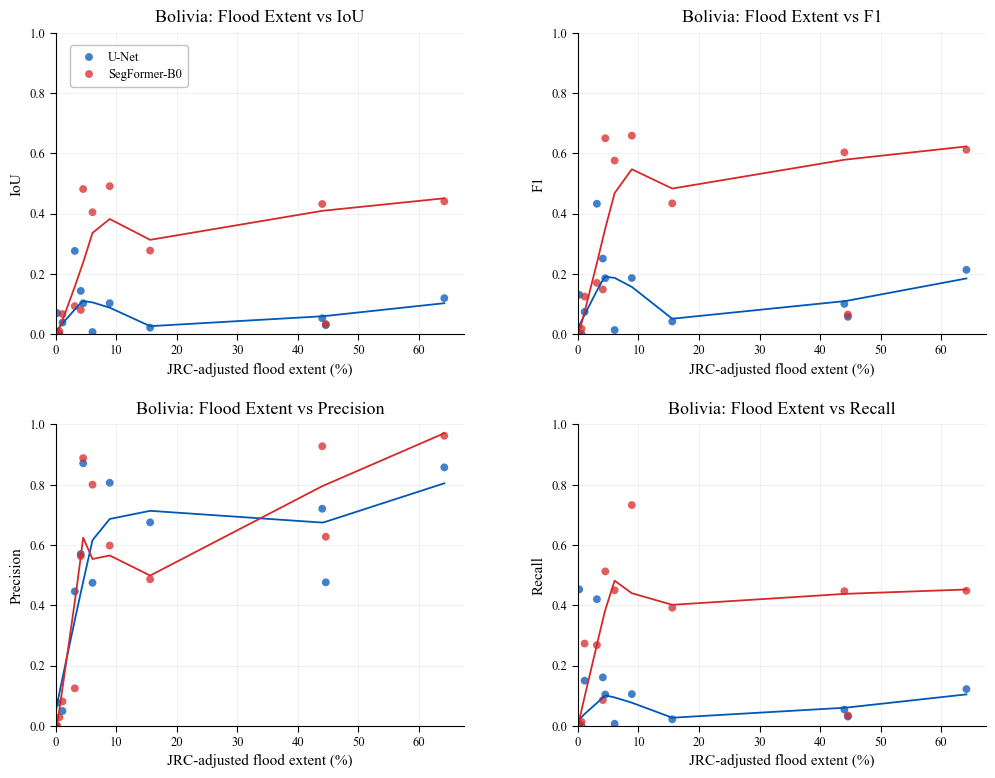

In [53]:
# Bolivia scatterplots with LOWESS:

MODEL_COLORS = {
    "U-Net": "#0057B8",          # stronger blue
    "SegFormer-B0": "#D62828"    # stronger red
}


plt.rcParams["font.family"] = "Times New Roman"
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

metrics = ["IoU", "F1", "Precision", "Recall"]
x_max = bolivia_analysis["flood_extent"].max()
x_max = x_max * 1.05

for ax, metric in zip(axes.ravel(), metrics):

    for model_name in ["U-Net", "SegFormer-B0"]:

        subset = bolivia_analysis[
            (bolivia_analysis["model"] == model_name) &
            (bolivia_analysis[metric].notna())].copy()

        x = subset["flood_extent"].to_numpy()
        y = subset[metric].to_numpy()

        # Scatter obs.
        ax.scatter(x, y,
            color=MODEL_COLORS[model_name],
            alpha=0.75,
            s=32,
            edgecolors="none",
            label=model_name)

        # LOWESS curve
        if len(subset) >= 4:

            lowess_result = lowess(y, x,
                frac=0.75,
                return_sorted=True)

            ax.plot(lowess_result[:, 0],
                lowess_result[:, 1],
                color=MODEL_COLORS[model_name],
                linewidth=1.3)

    ax.set_xlabel("JRC-adjusted flood extent (%)", fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(
        f"Bolivia: Flood Extent vs {metric}",
        fontsize=13,
        fontweight="normal",
        pad=8)
    ax.set_xlim(
        left=0,
        right=x_max)
    ax.set_ylim(
        bottom=0,
        top=1.0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=0.8,
        labelsize=9)
    # Light grid lines
    ax.grid(
        True,
        which="major",
        linestyle="-",
        linewidth=0.5,
        alpha=0.25)

# Legend
axes[0, 0].legend(
    fontsize=9,
    frameon=True,
    edgecolor="0.7",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    borderpad=0.5,
    handletextpad=0.5,
    labelspacing=0.4)
# Spacing 
plt.subplots_adjust(wspace=0.28, hspace=0.30)

# Save high-resolution figure
pdf_path = PDF_DIR / "bolivia_flood_extent_relationships_publication.pdf"
plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight")
png_path = FIGURES_DIR / "bolivia_flood_extent_relationships_publication.png"
plt.savefig(
    png_path,
    format="png",
    dpi=300,
    bbox_inches="tight")

plt.show()

------------------------
###### 5
## Section 5: Qualitative Error Analysis
###### 5.1
### Section 5.1 - Scene-level comparison table

In [54]:
# Combining U-Net and SegFormer scene results:

# Using only the principal test population, not sensitivty tests.
qualitative_data = principal_test_results.copy()

# Keeping one row per scene/model and selecting the main fields.
qualitative_data = qualitative_data[["scene_id", "flood_event", "model",
        "flood_extent", "IoU", "F1", "Precision", "Recall"]].copy()

# Pivot so each scene has U-Net and SegFormer side by side.
qualitative_wide = qualitative_data.pivot(index=["scene_id", "flood_event", "flood_extent"],
                                          columns="model", values=["IoU", "F1", "Precision", "Recall"])

# Flattening the column names.
qualitative_wide.columns = [f"{metric}_{model.replace('-', '_').replace(' ', '_')}"
    for metric, model in qualitative_wide.columns]

qualitative_wide = qualitative_wide.reset_index()

display(qualitative_wide.head())

,scene_id,flood_event,flood_extent,IoU_SegFormer_B0,IoU_U_Net,F1_SegFormer_B0,F1_U_Net,Precision_SegFormer_B0,Precision_U_Net,Recall_SegFormer_B0,Recall_U_Net
0,Ghana_1078550,Ghana,0.536728,0.000000,0.041491,0.000000,0.079676,NaN,0.797297,0.000000,0.041933
1,Ghana_141271,Ghana,0.624084,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000
2,Ghana_167233,Ghana,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ghana_313799,Ghana,6.108466,0.043059,0.018680,0.082563,0.036674,1.000000,0.989362,0.043059,0.018683
4,Ghana_319168,Ghana,23.027665,0.175756,0.319343,0.298966,0.484094,0.890171,0.946876,0.179651,0.325169


###### 5.2
### Section 5.2 - flood-extent categories

I am using categories only for qualitative selection, not for the main statistical analysis. The actual statistical analysis remains continuous, as specified in the methodology.

In [55]:
# Defining the qualitative flood-extent categories:

def extent_category(extent):
    """Assign a descriptive flood-extent category."""
    
    if extent < 5:
        return "Low (<5%)"
    elif extent < 25:
        return "Intermediate (5–25%)"
    else:
        return "High (>=25%)"

qualitative_wide["extent_category"] = (qualitative_wide["flood_extent"].apply(extent_category))

display(qualitative_wide[["scene_id", "flood_event", "flood_extent",
            "extent_category", "IoU_U_Net", "IoU_SegFormer_B0"]].sort_values("flood_extent"))

,scene_id,flood_event,flood_extent,extent_category,IoU_U_Net,IoU_SegFormer_B0
2,Ghana_167233,Ghana,0.000000,Low (<5%),NaN,NaN
35,Pakistan_528249,Pakistan,0.000000,Low (<5%),0.000000,0.000000
7,Ghana_53713,Ghana,0.000000,Low (<5%),NaN,NaN
44,Paraguay_40936,Paraguay,0.000000,Low (<5%),0.000000,0.000000
9,Ghana_97059,Ghana,0.000000,Low (<5%),0.000000,0.000000
...,...,...,...,...,...,...
17,India_747992,India,44.764525,High (>=25%),0.164728,0.198458
20,India_80221,India,48.921228,High (>=25%),0.511987,0.504592
63,Spain_7387658,Spain,51.599080,High (>=25%),0.683840,0.034526
24,Mekong_1443339,Mekong,65.125985,High (>=25%),0.780751,0.672357


In [56]:
# Calculation for model differences:
# (useful because some scenes may be valuable specifically because the two architectures behave differently).

qualitative_wide["IoU_difference"] = (qualitative_wide["IoU_U_Net"] - qualitative_wide["IoU_SegFormer_B0"]).abs()
qualitative_wide["mean_IoU"] = (qualitative_wide["IoU_U_Net"] + qualitative_wide["IoU_SegFormer_B0"]) / 2

display(qualitative_wide[["scene_id", "flood_event", "flood_extent", "extent_category",
            "IoU_U_Net", "IoU_SegFormer_B0", "mean_IoU", "IoU_difference"]].sort_values("IoU_difference", ascending=False).head(15))

,scene_id,flood_event,flood_extent,extent_category,IoU_U_Net,IoU_SegFormer_B0,mean_IoU,IoU_difference
33,Nigeria_812045,Nigeria,43.750369,High (>=25%),0.782667,0.004929,0.393798,0.777738
63,Spain_7387658,Spain,51.599080,High (>=25%),0.683840,0.034526,0.359183,0.649314
43,Paraguay_280900,Paraguay,2.415866,Low (<5%),0.589494,0.021266,0.305380,0.568228
42,Paraguay_271769,Paraguay,0.971985,Low (<5%),0.551136,0.001179,0.276158,0.549957
62,Spain_7370579,Spain,26.726326,High (>=25%),0.650759,0.153810,0.402284,0.496949
6,Ghana_406026,Ghana,1.638794,Low (<5%),0.792913,0.345467,0.569190,0.447446
52,Paraguay_913449,Paraguay,2.099609,Low (<5%),0.445474,0.034304,0.239889,0.411171
21,India_828067,India,3.566514,Low (<5%),0.453976,0.085821,0.269899,0.368155
78,USA_527077,USA,0.526462,Low (<5%),0.369436,0.004476,0.186956,0.364960
84,USA_778194,USA,0.980272,Low (<5%),0.403057,0.092728,0.247892,0.310329


In [57]:
# Low-extent candidate failures:

low_extent_failures = (qualitative_wide[(qualitative_wide["flood_extent"] < 5) &
        (qualitative_wide["mean_IoU"].notna())].sort_values("mean_IoU"))

display(low_extent_failures[["scene_id", "flood_event", "flood_extent",
            "IoU_U_Net", "IoU_SegFormer_B0", "F1_U_Net", "F1_SegFormer_B0", "mean_IoU"]].head(10))

,scene_id,flood_event,flood_extent,IoU_U_Net,IoU_SegFormer_B0,F1_U_Net,F1_SegFormer_B0,mean_IoU
35,Pakistan_528249,Pakistan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Ghana_141271,Ghana,0.624084,0.000000,0.000000,0.000000,0.000000,0.000000
53,Somalia_166342,Somalia,0.005440,0.000000,0.000000,0.000000,0.000000,0.000000
9,Ghana_97059,Ghana,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12,India_44475,India,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50,Paraguay_80102,Paraguay,0.008392,0.000000,0.000000,0.000000,0.000000,0.000000
44,Paraguay_40936,Paraguay,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
36,Pakistan_664885,Pakistan,0.013697,0.000670,0.000000,0.001340,0.000000,0.000335
68,Sri-Lanka_534068,Sri-Lanka,0.447845,0.001561,0.000000,0.003117,0.000000,0.000780
55,Somalia_60129,Somalia,0.304521,0.000000,0.002883,0.000000,0.005749,0.001441


In [58]:
# Low-extent successful examples:

low_extent_successes = (qualitative_wide[(qualitative_wide["flood_extent"] < 5) & (qualitative_wide["mean_IoU"].notna())].sort_values("mean_IoU", ascending=False))

display(low_extent_successes[["scene_id", "flood_event", "flood_extent",
            "IoU_U_Net", "IoU_SegFormer_B0", "F1_U_Net", "F1_SegFormer_B0", "mean_IoU"]].head(10))

,scene_id,flood_event,flood_extent,IoU_U_Net,IoU_SegFormer_B0,F1_U_Net,F1_SegFormer_B0,mean_IoU
27,Mekong_382276,Mekong,3.741926,0.503302,0.724616,0.669595,0.840321,0.613959
6,Ghana_406026,Ghana,1.638794,0.792913,0.345467,0.884497,0.513527,0.569190
5,Ghana_359826,Ghana,1.333618,0.396755,0.263527,0.568109,0.417129,0.330141
28,Mekong_424793,Mekong,1.548627,0.395262,0.258050,0.566578,0.410238,0.326656
43,Paraguay_280900,Paraguay,2.415866,0.589494,0.021266,0.741738,0.041647,0.305380
48,Paraguay_683296,Paraguay,1.665395,0.331577,0.273474,0.498021,0.429493,0.302525
86,USA_933610,USA,0.904869,0.407833,0.166033,0.579377,0.284783,0.286933
42,Paraguay_271769,Paraguay,0.971985,0.551136,0.001179,0.710623,0.002356,0.276158
21,India_828067,India,3.566514,0.453976,0.085821,0.624462,0.158077,0.269899
84,USA_778194,USA,0.980272,0.403057,0.092728,0.574541,0.169718,0.247892


In [59]:
# Intermediate-extent:

intermediate_candidates = (qualitative_wide[
        (qualitative_wide["flood_extent"] >= 5) &
        (qualitative_wide["flood_extent"] < 25) &
        (qualitative_wide["mean_IoU"].notna())].copy())

# Calculating how representative each scene is of the average performance within the intermediate-extent group.
intermediate_candidates["distance_from_mean"] = (intermediate_candidates["mean_IoU"] - intermediate_candidates["mean_IoU"].mean()).abs()

# Sort first, then select the columns we want to display.
display(intermediate_candidates.sort_values("distance_from_mean")
    [
        [
            "scene_id",
            "flood_event",
            "flood_extent",
            "IoU_U_Net",
            "IoU_SegFormer_B0",
            "mean_IoU"
        ]].head(10))

,scene_id,flood_event,flood_extent,IoU_U_Net,IoU_SegFormer_B0,mean_IoU
4,Ghana_319168,Ghana,23.027665,0.319343,0.175756,0.247549
40,Paraguay_1029191,Paraguay,5.001240,0.322166,0.176924,0.249545
51,Paraguay_868895,Paraguay,7.857407,0.263627,0.265118,0.264372
10,India_1018327,India,12.959770,0.220141,0.221784,0.220963
37,Pakistan_694942,Pakistan,9.653476,0.419862,0.121631,0.270746
14,India_591317,India,15.221358,0.216862,0.170239,0.193551
60,Spain_6095801,Spain,8.675810,0.385627,0.262807,0.324217
79,USA_595451,USA,7.788324,0.334470,0.316114,0.325292
58,Somalia_94102,Somalia,5.259364,0.371469,0.283539,0.327504
41,Paraguay_232281,Paraguay,11.244583,0.451686,0.219344,0.335515


In [60]:
# High-extent candidates:

high_extent_candidates = (qualitative_wide[
        (qualitative_wide["flood_extent"] >= 25) &
        (qualitative_wide["IoU_difference"].notna())].sort_values("IoU_difference", ascending=False))

display(high_extent_candidates[
        [
            "scene_id",
            "flood_event",
            "flood_extent",
            "IoU_U_Net",
            "IoU_SegFormer_B0",
            "F1_U_Net",
            "F1_SegFormer_B0",
            "IoU_difference"
        ]])

qualitative_wide.to_csv(RESULTS_TABLE_DIR / "qualitative_scene_comparison.csv", index=False)


,scene_id,flood_event,flood_extent,IoU_U_Net,IoU_SegFormer_B0,F1_U_Net,F1_SegFormer_B0,IoU_difference
33,Nigeria_812045,Nigeria,43.750369,0.782667,0.004929,0.878085,0.009809,0.777738
63,Spain_7387658,Spain,51.599080,0.683840,0.034526,0.812239,0.066748,0.649314
62,Spain_7370579,Spain,26.726326,0.650759,0.153810,0.788436,0.266612,0.496949
11,India_399883,India,39.654508,0.308221,0.152675,0.471207,0.264906,0.155546
24,Mekong_1443339,Mekong,65.125985,0.780751,0.672357,0.876879,0.804083,0.108394
39,Pakistan_849790,Pakistan,66.828125,0.118885,0.010641,0.212507,0.021058,0.108244
17,India_747992,India,44.764525,0.164728,0.198458,0.282861,0.331189,0.033730
8,Ghana_866994,Ghana,39.989448,0.102604,0.069230,0.186112,0.129495,0.033374
22,India_900498,India,27.312284,0.332968,0.324733,0.499589,0.490262,0.008235
20,India_80221,India,48.921228,0.511987,0.504592,0.677238,0.670736,0.007395


###### 5.3
### Section 5.3 - Flood Scene Selection

In [62]:
# 5.5 Qualitative Error Analysis:

import nbformat
import torch.nn as nn
import torch.nn.functional as F
from transformers import (SegformerConfig, SegformerForSemanticSegmentation)

# using Notebook 4:
MODEL_NOTEBOOK = list(PROJECT_DIR.rglob("04_Model_Training_NEW.ipynb"))[0]
nb = nbformat.read(MODEL_NOTEBOOK, as_version=4)

# Extract the exact model-definition code
model_code = ""

for cell in nb.cells:

    if cell.cell_type != "code":
        continue

    source = cell.source

    if (
        "class DoubleConv" in source
        or "class UNet" in source
        or "class SegFormerB0Binary" in source
    ):
        model_code += "\n\n" + source


# Executing the exact definitions
exec(model_code, globals())


# Paths
DATA_DIR = PROJECT_DIR / "Data"
RESULTS_DIR = PROJECT_DIR / "results_new"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

SEN1_ROOT = (DATA_DIR / "Sen1Floods11_raw" / "v1.1" / "data")
S1_HAND_DIR = (SEN1_ROOT / "flood_events" / "HandLabeled" / "S1Hand")
LABEL_HAND_DIR = (SEN1_ROOT / "flood_events" / "HandLabeled" / "LabelHand")
JRC_WATER_HAND_DIR = (SEN1_ROOT / "flood_events" / "HandLabeled" / "JRCWaterHand")

# the device and checkpoints
DEVICE = torch.device("cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu")

UNET_CHECKPOINT = (RESULTS_DIR / "models" / "unet_best.pt")
SEGFORMER_CHECKPOINT = (RESULTS_DIR / "models" / "segformer_b0_best.pt")
unet_checkpoint = torch.load(UNET_CHECKPOINT, map_location=DEVICE, weights_only=False)
segformer_checkpoint = torch.load(SEGFORMER_CHECKPOINT, map_location=DEVICE, weights_only=False)

# Instantiate exact trained models again for the figure generation:
unet = UNet(in_channels=2,out_channels=1)
segformer = SegFormerB0Binary()
unet.load_state_dict(unet_checkpoint["model_state_dict"])
segformer.load_state_dict(segformer_checkpoint["model_state_dict"])
unet = unet.to(DEVICE)
segformer = segformer.to(DEVICE)
unet.eval()
segformer.eval()


# normalization stats.
VV_MEAN = unet_checkpoint["vv_mean"]
VV_STD = unet_checkpoint["vv_std"]
VH_MEAN = unet_checkpoint["vh_mean"]
VH_STD = unet_checkpoint["vh_std"]


print("Models loaded.")
print("Device:", DEVICE)
print("U-Net parameters:", sum(p.numel() for p in unet.parameters()))
print("SegFormer parameters:", sum(p.numel() for p in segformer.parameters()))

Models loaded.
Device: mps
U-Net parameters: 31037057
SegFormer parameters: 3712833


In [149]:
# qualitative cases:

SELECTED_SCENES = ["USA_905409", "Spain_7387658", "India_80221"]

def find_scene_file(directory, scene_id):
    """Find the TIFF file corresponding to a scene."""

    matches = list(directory.glob(f"{scene_id}*.tif"))

    if not matches:
        raise FileNotFoundError(f"No TIFF found for {scene_id}")

    return matches[0]

In [150]:
# Generated the predictions for selected scenes:

import rasterio

def predict_scene(scene_id, model):

    s1_path = find_scene_file(S1_HAND_DIR,scene_id)
    label_path = find_scene_file(LABEL_HAND_DIR, scene_id)

    # raw data
    with rasterio.open(s1_path) as src: image = src.read().astype(np.float32)

    with rasterio.open(label_path) as src: label = src.read(1)

    jrc_path = find_scene_file(JRC_WATER_HAND_DIR, scene_id)

    with rasterio.open(jrc_path) as src: jrc = src.read(1)

    label_target = (label == 1)

    # matching valid qualitative mask to the SAR filtering 
    sar_valid_mask = (np.isfinite(image[0]) & np.isfinite(image[1]))
    valid_mask = ((label != -1) & sar_valid_mask)
    flood_target = (label_target & (jrc == 0) & valid_mask)


    # Replace the input NaNs with training-set channel means
    image_clean = image.copy()
    image_clean[0] = np.nan_to_num(image_clean[0], nan=VV_MEAN)
    image_clean[1] = np.nan_to_num(image_clean[1], nan=VH_MEAN)

    # Training normalization
    image_normalised = image_clean.copy()
    image_normalised[0] = (image_normalised[0] - VV_MEAN) / VV_STD
    image_normalised[1] = (image_normalised[1] - VH_MEAN) / VH_STD

    # Model input
    tensor = torch.from_numpy(image_normalised).unsqueeze(0).to(DEVICE)

    # Prediction
    with torch.no_grad():

        logits = model(tensor)

        probability = torch.sigmoid(logits)[0, 0].cpu().numpy()

    prediction = (probability >= 0.5)

    return {
        "scene_id": scene_id,
        "image": image_clean,
        "label_target": label_target,
        "target": flood_target,
        "valid_mask": valid_mask,
        "prediction": prediction}


# Generate both model predictions
qualitative_results = {}

for scene_id in SELECTED_SCENES:

    qualitative_results[scene_id] = {
        "U-Net": predict_scene(scene_id, unet),
        "SegFormer-B0": predict_scene(scene_id, segformer)}

    print(f"Processed {scene_id}")

Processed USA_905409
Processed Spain_7387658
Processed India_80221


In [151]:
# Verify qualitative predictions

verification_rows = []

for scene_id in SELECTED_SCENES:

    for model_name in [
        "U-Net",
        "SegFormer-B0"
    ]:

        result = qualitative_results[scene_id][model_name]

        prediction = result["prediction"]
        target = result["target"]
        valid = result["valid_mask"]

        prediction_valid = prediction[valid]
        target_valid = target[valid]

        tp = np.sum(prediction_valid & target_valid)
        fp = np.sum(prediction_valid & ~target_valid)
        fn = np.sum(~prediction_valid & target_valid)

        iou = (tp / (tp + fp + fn)
            if (tp + fp + fn) > 0
            else np.nan)

        verification_rows.append({"scene_id": scene_id, "model": model_name,"IoU_extracted": iou})

verification = pd.DataFrame(verification_rows)

# Existing results already used in the statistics
authoritative = principal_test_results[
    principal_test_results["scene_id"].isin(SELECTED_SCENES)][["scene_id", "model", "IoU"]].rename(columns={"IoU": "IoU_existing"})

comparison = verification.merge(authoritative, on=["scene_id", "model"], how="left")
comparison["difference"] = (comparison["IoU_extracted"] - comparison["IoU_existing"]).abs()

display(comparison.round(6))

,scene_id,model,IoU_extracted,IoU_existing,difference
0,USA_905409,U-Net,0.076270,0.076270,0.0
1,USA_905409,SegFormer-B0,0.023285,0.023285,0.0
2,Spain_7387658,U-Net,0.683840,0.683840,0.0
3,Spain_7387658,SegFormer-B0,0.034526,0.034526,0.0
4,India_80221,U-Net,0.511987,0.511987,0.0
5,India_80221,SegFormer-B0,0.504592,0.504592,0.0


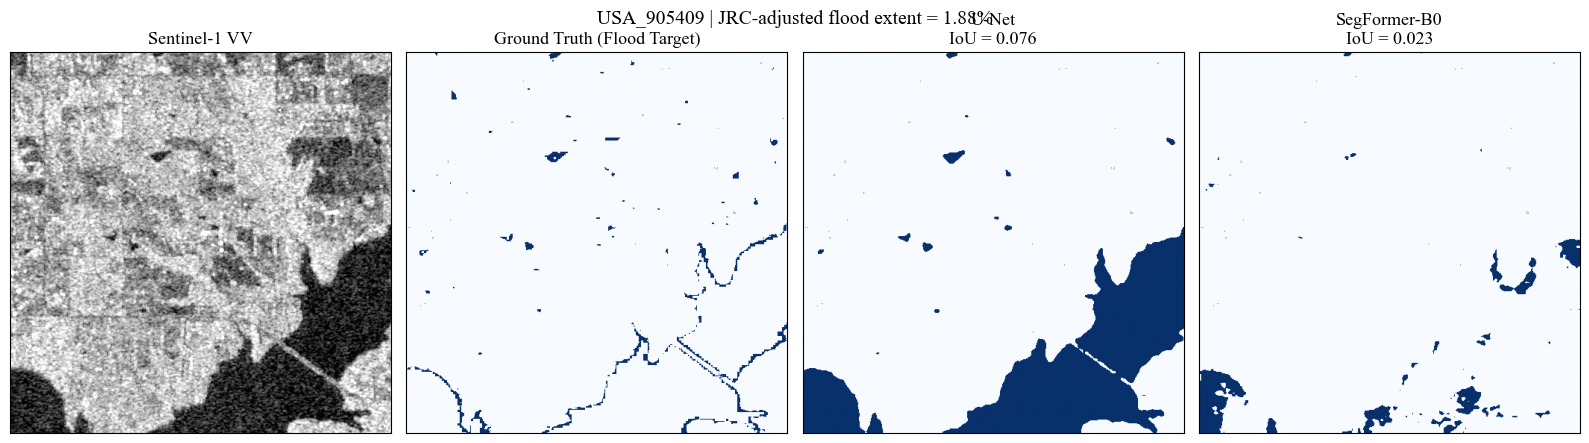

Saved: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/qualitative/USA_905409_qualitative.png


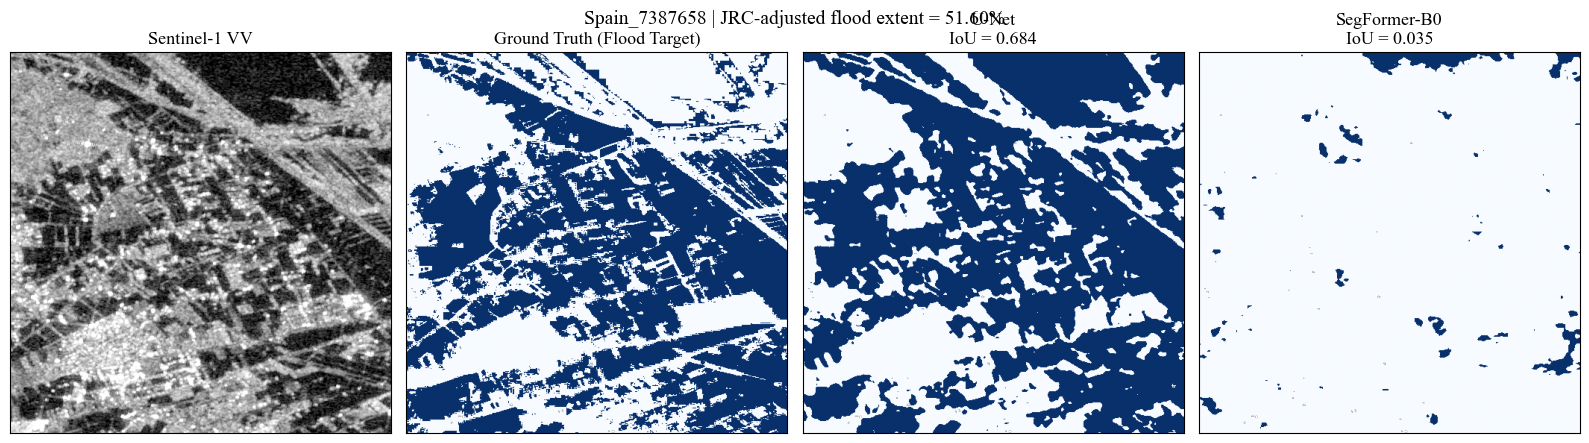

Saved: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/qualitative/Spain_7387658_qualitative.png


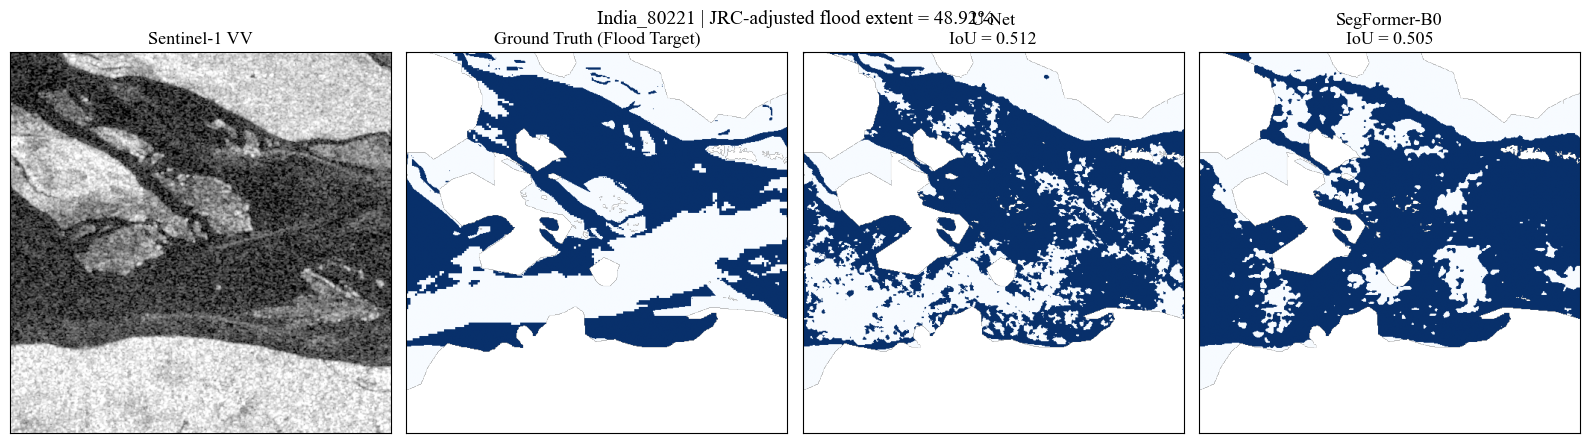

Saved: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/qualitative/India_80221_qualitative.png


In [152]:
# Qualitative figures:

QUAL_FIG_DIR = (FIGURES_DIR / "qualitative")
QUAL_FIG_DIR.mkdir(parents=True, exist_ok=True)


for scene_id in SELECTED_SCENES:

    scene_results = qualitative_results[scene_id]

    # Data
    vv = scene_results["U-Net"]["image"][0]

    target = scene_results["U-Net"]["target"]
    label_target = scene_results["U-Net"]["label_target"]
    valid = scene_results["U-Net"]["valid_mask"]

    unet_prediction = (scene_results["U-Net"]["prediction"])

    segformer_prediction = (scene_results["SegFormer-B0"]["prediction"])

    # Mask invalid pixels
    target_display = target.astype(float)
    unet_display = unet_prediction.astype(float)
    segformer_display = segformer_prediction.astype(float)

    target_display[~valid] = np.nan
    unet_display[~valid] = np.nan
    segformer_display[~valid] = np.nan

    # Flood extent and IoU values
    scene_data = principal_test_results[principal_test_results["scene_id"] == scene_id]
    flood_extent = scene_data["flood_extent"].iloc[0]
    unet_iou = scene_data[scene_data["model"] == "U-Net"]["IoU"].iloc[0]
    segformer_iou = scene_data[scene_data["model"] == "SegFormer-B0"]["IoU"].iloc[0]

    # VV display range
    vv_valid = vv[np.isfinite(vv)]

    if len(vv_valid) > 0:

        vmin, vmax = np.percentile(vv_valid, [2, 98])

    else:

        vmin, vmax = 0, 1

    # Figure
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

    axes[0].imshow(vv,
        cmap="gray",
        vmin=vmin,
        vmax=vmax)

    axes[0].set_title("Sentinel-1 VV")

    axes[1].imshow(target_display,
        cmap="Blues",
        vmin=0,
        vmax=1)

    axes[1].set_title("Ground Truth (Flood Target)")

    axes[2].imshow(unet_display,
        cmap="Blues",
        vmin=0,
        vmax=1)

    axes[2].set_title(f"U-Net\nIoU = {unet_iou:.3f}")

    axes[3].imshow(segformer_display,
        cmap="Blues",
        vmin=0,
        vmax=1)

    axes[3].set_title(f"SegFormer-B0\nIoU = {segformer_iou:.3f}")

    for ax in axes:

        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"{scene_id} | "
        f"JRC-adjusted flood extent = "
        f"{flood_extent:.2f}%",
        fontsize=14)

    plt.tight_layout()

    output_path = (QUAL_FIG_DIR /f"{scene_id}_qualitative.png")

    plt.savefig(output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")

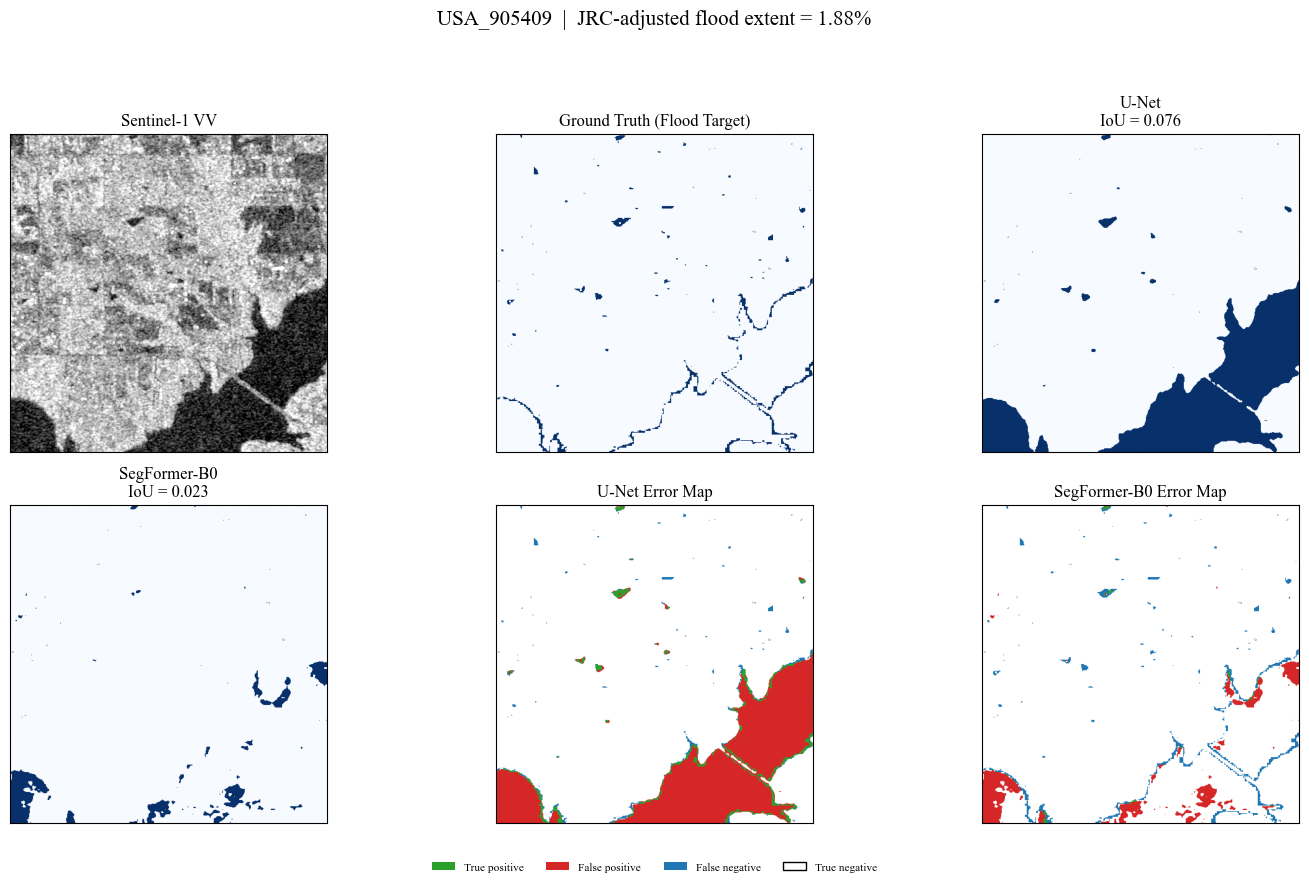

Saved: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/qualitative/USA_905409_qualitative_final.png


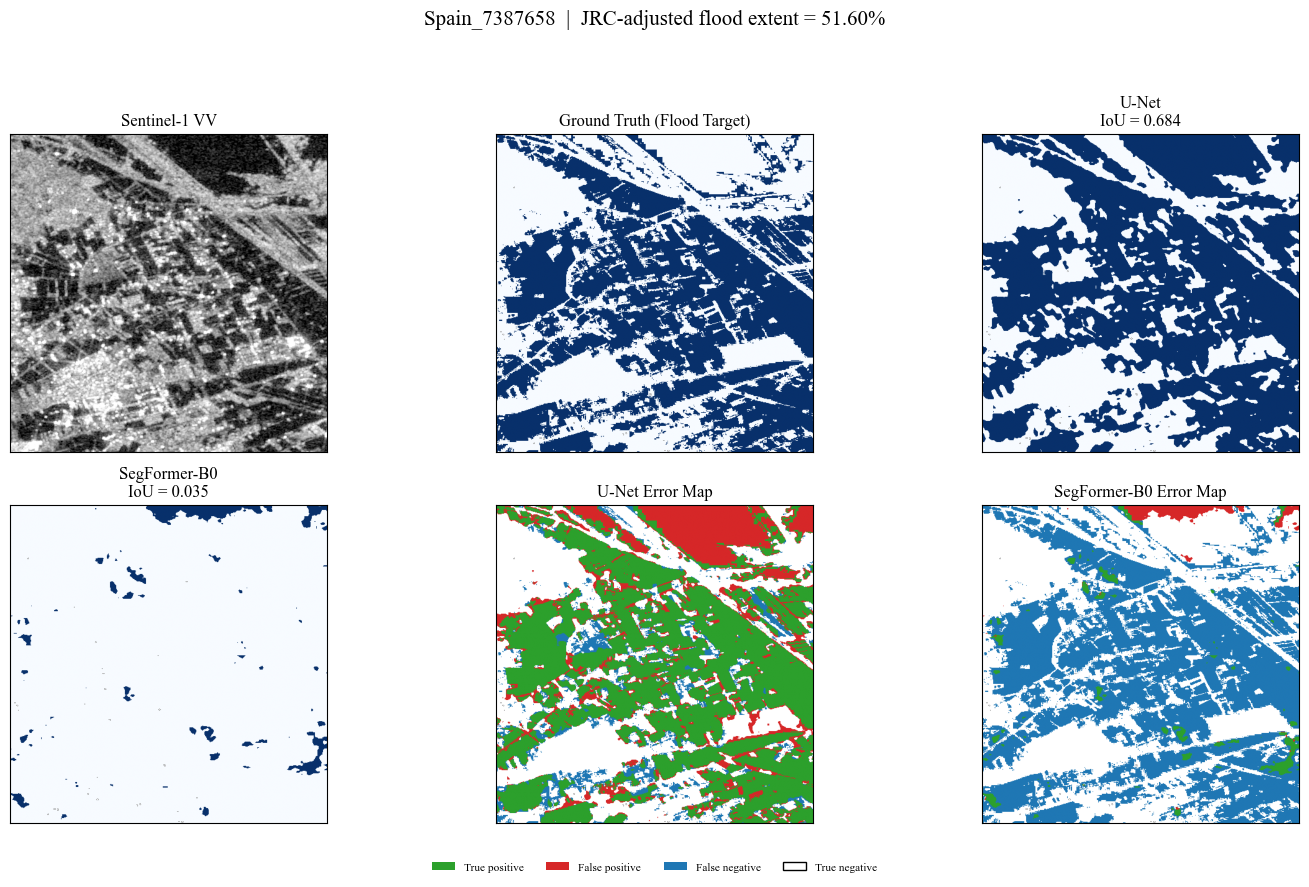

Saved: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/qualitative/Spain_7387658_qualitative_final.png


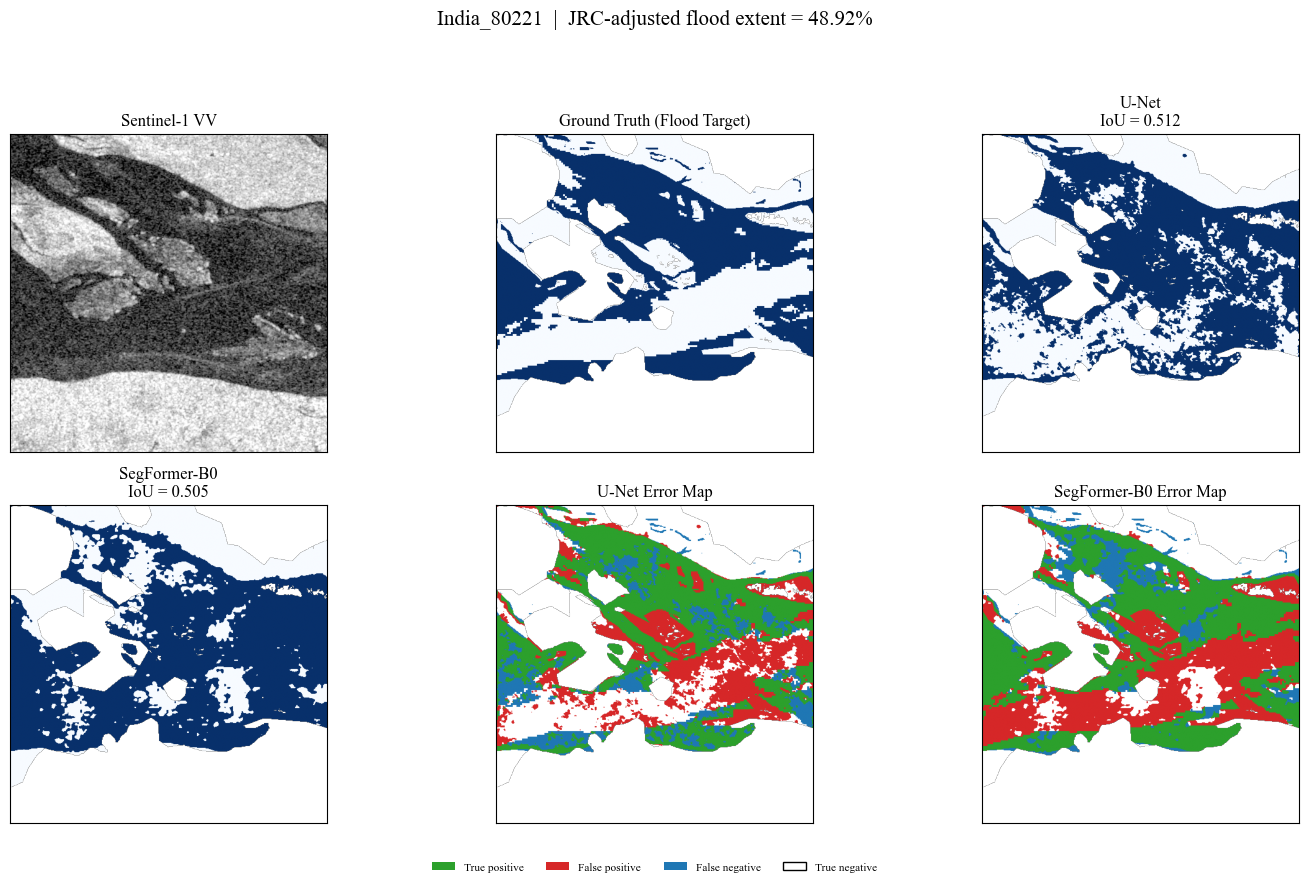

Saved: /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/results_new/figures/qualitative/India_80221_qualitative_final.png


In [ ]:
# Final qualitative figures for the dissertation

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

QUAL_FIG_DIR = FIGURES_DIR / "qualitative"
QUAL_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SELECTED_SCENES = [
    "USA_905409",
    "Spain_7387658",
    "India_80221"
]


def make_error_map(prediction, target, valid_mask):
    """
    Create a categorical error map.

    0 = correctly classified non-flood
    1 = true positive
    2 = false positive
    3 = false negative
    255 = invalid
    """

    error = np.zeros(
        target.shape,
        dtype=np.uint8
    )

    valid_pred = prediction[valid_mask]
    valid_target = target[valid_mask]

    # True positives
    tp = (
        prediction &
        target &
        valid_mask
    )

    # False positives
    fp = (
        prediction &
        ~target &
        valid_mask
    )

    # False negatives
    fn = (
        ~prediction &
        target &
        valid_mask
    )

    error[tp] = 1
    error[fp] = 2
    error[fn] = 3

    error[~valid_mask] = 255

    return error


# Error-map colours
error_cmap = ListedColormap([
    "white",      # 0: true negative
    "#2ca02c",    # 1: true positive
    "#d62728",    # 2: false positive
    "#1f77b4"     # 3: false negative
])


# Generating each figure
for scene_id in SELECTED_SCENES:

    scene_results = qualitative_results[scene_id]

    unet_result = scene_results["U-Net"]
    segformer_result = scene_results["SegFormer-B0"]

    vv = unet_result["image"][0]
    target = unet_result["target"]
    valid_mask = unet_result["valid_mask"]

    unet_prediction = unet_result["prediction"]
    segformer_prediction = segformer_result["prediction"]

    # Flood extent and IoU values from authoritative results
    scene_data = principal_test_results[
        principal_test_results["scene_id"] == scene_id
    ]

    flood_extent = scene_data[
        "flood_extent"
    ].iloc[0]

    unet_iou = scene_data[
        scene_data["model"] == "U-Net"
    ]["IoU"].iloc[0]

    segformer_iou = scene_data[
        scene_data["model"] == "SegFormer-B0"
    ]["IoU"].iloc[0]

    # error maps
    unet_error = make_error_map(
        unet_prediction,
        target,
        valid_mask
    )

    segformer_error = make_error_map(
        segformer_prediction,
        target,
        valid_mask
    )

    # Mask invalid pixels
    unet_error_display = (
        unet_error.astype(float)
    )
    segformer_error_display = (
        segformer_error.astype(float)
    )

    unet_error_display[
        unet_error == 255
    ] = np.nan

    segformer_error_display[
        segformer_error == 255
    ] = np.nan

    # Binary mask displays
    target_display = target.astype(float)
    unet_display = unet_prediction.astype(float)
    segformer_display = segformer_prediction.astype(float)

    target_display[~valid_mask] = np.nan
    unet_display[~valid_mask] = np.nan
    segformer_display[~valid_mask] = np.nan

    # Sentinel-1 display
    vv_valid = vv[np.isfinite(vv)]

    # Paraguay_34417 has an entirely NaN SAR input
    has_valid_vv = len(vv_valid) > 0

    if has_valid_vv:

        vmin, vmax = np.percentile(
            vv_valid,
            [2, 98]
        )

    # figure:
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 9)
    )

    # Panel 1 — Sentinel-1 VV
    if has_valid_vv:

        axes[0, 0].imshow(
            vv,
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )

        axes[0, 0].set_title(
            "Sentinel-1 VV",
            fontsize=12
        )

    else:

        axes[0, 0].set_facecolor("black")

        axes[0, 0].text(
            0.5,
            0.5,
            "Sentinel-1 VV\n"
            "all pixels are NaN\n"
            "(no valid SAR values)",
            ha="center",
            va="center",
            color="white",
            fontsize=12,
            transform=axes[0, 0].transAxes
        )

        axes[0, 0].set_title(
            "Sentinel-1 VV",
            fontsize=12
        )

    # Panel 2 is the Ground truth
    axes[0, 1].imshow(
        target_display,
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    axes[0, 1].set_title(
        "Ground Truth (Flood Target)",
        fontsize=12
    )

    # Panel 3 — U-Net
    axes[0, 2].imshow(
        unet_display,
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    axes[0, 2].set_title(
        f"U-Net\nIoU = {unet_iou:.3f}",
        fontsize=12
    )

    # Panel 4 — SegFormer
    axes[1, 0].imshow(
        segformer_display,
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    axes[1, 0].set_title(
        f"SegFormer-B0\nIoU = {segformer_iou:.3f}",
        fontsize=12
    )

    # Panel 5 — U-Net error map
    axes[1, 1].imshow(
        unet_error_display,
        cmap=error_cmap,
        vmin=0,
        vmax=3
    )

    axes[1, 1].set_title(
        "U-Net Error Map",
        fontsize=12
    )

    # Panel 6 — SegFormer error map
    axes[1, 2].imshow(
        segformer_error_display,
        cmap=error_cmap,
        vmin=0,
        vmax=3
    )

    axes[1, 2].set_title(
        "SegFormer-B0 Error Map",
        fontsize=12
    )

    # Formatting
    for ax in axes.ravel():

        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"{scene_id}  |  "
        f"JRC-adjusted flood extent = "
        f"{flood_extent:.2f}%",
        fontsize=15,
        y=0.98
    )

    # Error-map legend
    legend_elements = [
        Patch(
            facecolor="#2ca02c",
            label="True positive"
        ),
        Patch(
            facecolor="#d62728",
            label="False positive"
        ),
        Patch(
            facecolor="#1f77b4",
            label="False negative"
        ),
        Patch(
            facecolor="white",
            edgecolor="black",
            label="True negative"
        )
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, 0.01),
        frameon=False
    )

    plt.tight_layout(
        rect=[0, 0.06, 1, 0.94]
    )

    # Save:
    output_path = (
        QUAL_FIG_DIR /
        f"{scene_id}_qualitative_final.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {output_path}"
    )

In [153]:
unet_test["Accuracy"] = (
    unet_test["TP"] + unet_test["TN"]
) / (
    unet_test["TP"] + unet_test["TN"] +
    unet_test["FP"] + unet_test["FN"]
)

print("Mean U-Net accuracy:", unet_test["Accuracy"].mean())

Mean U-Net accuracy: 0.9117652033467892


In [156]:
segformer_test["Accuracy"] = (
    segformer_test["TP"] + segformer_test["TN"]
) / (
    segformer_test["TP"] + segformer_test["TN"] +
    segformer_test["FP"] + segformer_test["FN"]
)

print("Mean SegFormer-B0 accuracy:",
      segformer_test["Accuracy"].mean())

Mean SegFormer-B0 accuracy: 0.9093066651402242


In [155]:
unet_accuracy_pooled = (
    unet_test["TP"].sum() + unet_test["TN"].sum()
) / (
    unet_test["TP"].sum() +
    unet_test["TN"].sum() +
    unet_test["FP"].sum() +
    unet_test["FN"].sum()
)

segformer_accuracy_pooled = (
    segformer_test["TP"].sum() + segformer_test["TN"].sum()
) / (
    segformer_test["TP"].sum() +
    segformer_test["TN"].sum() +
    segformer_test["FP"].sum() +
    segformer_test["FN"].sum()
)

print("U-Net pooled accuracy:", unet_accuracy_pooled)
print("SegFormer pooled accuracy:", segformer_accuracy_pooled)

U-Net pooled accuracy: 0.9164011815678211
SegFormer pooled accuracy: 0.913178446832176
